# Supermarket Checkout Operations: Hypothesis Validation Notebook

This notebook loads the five XES event logs separately and performs hypothesis validation for the supermarket checkout assignment.

The analysis is structured around the main hypotheses:

1. Customers with fewer items are more sensitive to queue length and abandon more readily.
2. Payment method affects checkout duration and may contribute to queue buildup.
3. Absence of a manager may lead to slower staffing response and more abandonment.
4. High customer arrivals do not necessarily cause congestion if checkout capacity is sufficient.
5. Cashier shift handovers may create temporary bottlenecks.


## 1. Imports

In [1]:
import pm4py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


C:\Users\Sujitha\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 2. Load all XES logs

Ensure that all the `.xes` files are in the same folder as this notebook. 

In [2]:
customer_path = "Supermarket_Customer.xes"
cashier_path = "Supermarket_Cashier.xes"
manager_path = "Supermarket_Manager.xes"
counter_path = "Supermarket_Counter.xes"
clerk_path = "Supermarket_Clerk.xes"

customer_log = xes_importer.apply(customer_path)
cashier_log = xes_importer.apply(cashier_path)
manager_log = xes_importer.apply(manager_path)
counter_log = xes_importer.apply(counter_path)
clerk_log = xes_importer.apply(clerk_path)

print("Customer traces:", len(customer_log))
print("Cashier traces:", len(cashier_log))
print("Manager traces:", len(manager_log))
print("Counter traces:", len(counter_log))
print("Clerk traces:", len(clerk_log))


parsing log, completed traces ::   0%|          | 0/9557 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/37 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/18 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/10 [00:00<?, ?it/s]

Customer traces: 9557
Cashier traces: 37
Manager traces: 2
Counter traces: 18
Clerk traces: 10


## 3. Convert logs to pandas DataFrames

In [3]:
customer_df = log_converter.apply(customer_log, variant=log_converter.Variants.TO_DATA_FRAME)
cashier_df = log_converter.apply(cashier_log, variant=log_converter.Variants.TO_DATA_FRAME)
manager_df = log_converter.apply(manager_log, variant=log_converter.Variants.TO_DATA_FRAME)
counter_df = log_converter.apply(counter_log, variant=log_converter.Variants.TO_DATA_FRAME)
clerk_df = log_converter.apply(clerk_log, variant=log_converter.Variants.TO_DATA_FRAME)

for name, df in {
    'customer_df': customer_df,
    'cashier_df': cashier_df,
    'manager_df': manager_df,
    'counter_df': counter_df,
    'clerk_df': clerk_df,
}.items():
    print(name, df.shape)


customer_df (2441070, 21)
cashier_df (2928, 17)
manager_df (80, 5)
counter_df (1234898, 22)
clerk_df (32816, 10)


## 4. Standard cleanup and sanity checks

In [4]:
dfs = [customer_df, cashier_df, manager_df, counter_df, clerk_df]

for df in dfs:
    df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
    df['hour'] = df['time:timestamp'].dt.hour
    df['date'] = df['time:timestamp'].dt.date

print("Customer activities:")
display(customer_df['concept:name'].value_counts())

print("Cashier activities:")
display(cashier_df['concept:name'].value_counts())

print("Manager activities:")
display(manager_df['concept:name'].value_counts())


Customer activities:


concept:name
Pickup Item               1155096
Scan Item                 1127675
Enter store                 25955
Go to Checkout              25955
Enter Queue                 25325
Start Payment               25325
Complete Payment            25325
Start Price Check           14892
End price check             14892
Abandon cart and leave        630
Name: count, dtype: int64

Cashier activities:


concept:name
Start Shift      732
Open counter     732
Close counter    732
End shift        732
Name: count, dtype: int64

Manager activities:


concept:name
Start Shift    40
End Shift      40
Name: count, dtype: int64

## 5. Helper functions

In [5]:
def compute_waiting_times(customer_df):
    # Compute waiting time from Enter Queue to Start Payment per customer.
    waiting_events = customer_df[
        customer_df['concept:name'].isin(['Enter Queue', 'Start Payment'])
    ].copy()
    waiting_events = waiting_events.sort_values(['case:concept:name', 'time:timestamp'])

    rows = []
    for customer_id, group in waiting_events.groupby('case:concept:name'):
        enter_queue = group[group['concept:name'] == 'Enter Queue']['time:timestamp'].reset_index(drop=True)
        start_payment = group[group['concept:name'] == 'Start Payment']['time:timestamp'].reset_index(drop=True)
        n = min(len(enter_queue), len(start_payment))
        for i in range(n):
            wait_minutes = (start_payment[i] - enter_queue[i]).total_seconds() / 60
            if wait_minutes >= 0:
                rows.append({
                    'customer_id': customer_id,
                    'enter_queue_time': enter_queue[i],
                    'start_payment_time': start_payment[i],
                    'waiting_minutes': wait_minutes,
                    'hour': enter_queue[i].hour,
                    'date': enter_queue[i].date()
                })
    return pd.DataFrame(rows)


def compute_payment_durations(customer_df):
    # Compute payment duration from Start Payment to Complete Payment per customer.
    payment_events = customer_df[
        customer_df['concept:name'].isin(['Start Payment', 'Complete Payment'])
    ].copy()
    payment_events = payment_events.sort_values(['case:concept:name', 'time:timestamp'])

    rows = []
    for customer_id, group in payment_events.groupby('case:concept:name'):
        starts = group[group['concept:name'] == 'Start Payment'].reset_index(drop=True)
        completes = group[group['concept:name'] == 'Complete Payment'].reset_index(drop=True)
        n = min(len(starts), len(completes))
        for i in range(n):
            start_time = starts.loc[i, 'time:timestamp']
            end_time = completes.loc[i, 'time:timestamp']
            duration_minutes = (end_time - start_time).total_seconds() / 60
            if duration_minutes >= 0:
                rows.append({
                    'customer_id': customer_id,
                    'payment_method': starts.loc[i, 'p'] if 'p' in starts.columns else np.nan,
                    'start_payment_time': start_time,
                    'complete_payment_time': end_time,
                    'payment_duration_minutes': duration_minutes,
                    'hour': start_time.hour,
                    'date': start_time.date()
                })
    return pd.DataFrame(rows)


def compute_active_counters(cashier_df):
    events = cashier_df[cashier_df['concept:name'].isin(['Open counter', 'Close counter'])].copy()
    events['counter_delta'] = events['concept:name'].map({'Open counter': 1, 'Close counter': -1})
    events = events.sort_values('time:timestamp')
    events['active_counters'] = events['counter_delta'].cumsum()
    events['hour'] = events['time:timestamp'].dt.hour
    events['date'] = events['time:timestamp'].dt.date
    return events


def compute_active_cashiers(cashier_df):
    events = cashier_df[cashier_df['concept:name'].isin(['Start Shift', 'End shift', 'End Shift'])].copy()
    events['cashier_delta'] = events['concept:name'].map({'Start Shift': 1, 'End shift': -1, 'End Shift': -1})
    events = events.sort_values('time:timestamp')
    events['active_cashiers'] = events['cashier_delta'].cumsum()
    events['hour'] = events['time:timestamp'].dt.hour
    events['date'] = events['time:timestamp'].dt.date
    return events


def compute_manager_presence(manager_df):
    events = manager_df[manager_df['concept:name'].isin(['Start Shift', 'End shift', 'End Shift'])].copy()
    events['manager_delta'] = events['concept:name'].map({'Start Shift': 1, 'End shift': -1, 'End Shift': -1})
    events = events.sort_values('time:timestamp')
    events['manager_present'] = events['manager_delta'].cumsum() > 0
    events['hour'] = events['time:timestamp'].dt.hour
    events['date'] = events['time:timestamp'].dt.date
    return events


## 6. Create reusable analysis tables

In [6]:
waiting_df = compute_waiting_times(customer_df)
payment_duration_df = compute_payment_durations(customer_df)
active_counters_df = compute_active_counters(cashier_df)
active_cashiers_df = compute_active_cashiers(cashier_df)
manager_presence_df = compute_manager_presence(manager_df)

print("waiting_df", waiting_df.shape)
print("payment_duration_df", payment_duration_df.shape)
print("active_counters_df", active_counters_df.shape)
print("active_cashiers_df", active_cashiers_df.shape)
print("manager_presence_df", manager_presence_df.shape)

display(waiting_df.head())
display(payment_duration_df.head())


waiting_df (25325, 6)
payment_duration_df (25325, 7)
active_counters_df (1464, 21)
active_cashiers_df (1464, 21)
manager_presence_df (80, 9)


,customer_id,enter_queue_time,start_payment_time,waiting_minutes,hour,date
0,0,2026-01-26 14:03:27.627000+00:00,2026-01-26 14:06:23.209000+00:00,2.926367,14,2026-01-26
1,0,2026-02-09 14:03:42.324000+00:00,2026-02-09 14:06:47.585000+00:00,3.087683,14,2026-02-09
2,0,2026-02-20 14:03:26.511000+00:00,2026-02-20 14:06:23.327000+00:00,2.946933,14,2026-02-20
3,1,2026-01-26 14:05:57.614000+00:00,2026-01-26 14:07:33.733000+00:00,1.601983,14,2026-01-26
4,1,2026-02-09 14:07:23.361000+00:00,2026-02-09 14:11:11.126000+00:00,3.796083,14,2026-02-09


,customer_id,payment_method,start_payment_time,complete_payment_time,payment_duration_minutes,hour,date
0,0,Pin,2026-01-26 14:06:23.209000+00:00,2026-01-26 14:07:17.916000+00:00,0.911783,14,2026-01-26
1,0,Pin,2026-02-09 14:06:47.585000+00:00,2026-02-09 14:07:38.542000+00:00,0.849283,14,2026-02-09
2,0,Pin,2026-02-20 14:06:23.327000+00:00,2026-02-20 14:07:28.254000+00:00,1.082117,14,2026-02-20
3,1,Cash,2026-01-26 14:07:33.733000+00:00,2026-01-26 14:07:41.173000+00:00,0.124000,14,2026-01-26
4,1,Pin,2026-02-09 14:11:11.126000+00:00,2026-02-09 14:12:10.980000+00:00,0.997567,14,2026-02-09


## H1. Customers with fewer items are more sensitive to queue length

This analysis compares abandonment rates for customers with small baskets and large baskets.

Q1                    : 58.0
Q3                    : 71.0
IQR                   : 13.0
Lower outlier boundary: 38.50

Small basket threshold (data-driven): 38 items
  Customers with < 38 items : 552
  Customers with >= 38 items: 9005


,basket_group,customers,abandonment_rate
0,Large basket (>=38 items),9005,0.063076
1,Small basket (<38 items),552,0.036232


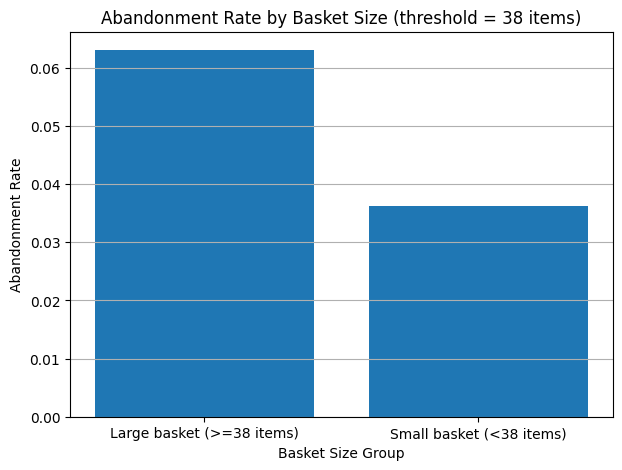

In [ ]:
# Build the items-per-customer table
items_per_customer = (
    customer_df
    .groupby('case:concept:name')['items']
    .max()
    .reset_index()
    .rename(columns={'case:concept:name': 'customer_id'})
)

abandoned_customers = customer_df[
    customer_df['concept:name'] == 'Abandon cart and leave'
]['case:concept:name'].unique()

items_per_customer['abandoned'] = items_per_customer['customer_id'].isin(abandoned_customers)

# Derive threshold from data distribution
Q1  = items_per_customer['items'].quantile(0.25)
Q3  = items_per_customer['items'].quantile(0.75)
IQR = Q3 - Q1
lower_outlier_boundary = Q1 - 1.5 * IQR

print(f"Q1                    : {Q1}")
print(f"Q3                    : {Q3}")
print(f"IQR                   : {IQR}")
print(f"Lower outlier boundary: {lower_outlier_boundary:.2f}")

SMALL_BASKET_THRESHOLD = max(2, int(lower_outlier_boundary))

print(f"\nSmall basket threshold (data-driven): {SMALL_BASKET_THRESHOLD} items")
print(f"  Customers with < {SMALL_BASKET_THRESHOLD} items : {(items_per_customer['items'] < SMALL_BASKET_THRESHOLD).sum()}")
print(f"  Customers with >= {SMALL_BASKET_THRESHOLD} items: {(items_per_customer['items'] >= SMALL_BASKET_THRESHOLD).sum()}")

# Apply the threshold
items_per_customer['basket_group'] = np.where(
    items_per_customer['items'] < SMALL_BASKET_THRESHOLD,
    f'Small basket (<{SMALL_BASKET_THRESHOLD} items)',
    f'Large basket (>={SMALL_BASKET_THRESHOLD} items)'
)

basket_summary = (
    items_per_customer
    .groupby('basket_group')
    .agg(customers=('customer_id', 'nunique'), abandonment_rate=('abandoned', 'mean'))
    .reset_index()
)

display(basket_summary)

plt.figure(figsize=(7, 5))
plt.bar(basket_summary['basket_group'], basket_summary['abandonment_rate'])
plt.title(f"Abandonment Rate by Basket Size (threshold = {SMALL_BASKET_THRESHOLD} items)")
plt.xlabel("Basket Size Group")
plt.ylabel("Abandonment Rate")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


Item range in data: 1 to 97
Searching all thresholds from 2 to 96...

Best threshold per day:


,date,best_threshold,difference
0,2026-01-26,88,0.106202
1,2026-01-27,8,0.244048
2,2026-01-28,10,0.208995
3,2026-01-29,86,0.090296
4,2026-01-30,8,0.250476
5,2026-01-31,12,0.227925
6,2026-02-01,52,0.073092
7,2026-02-02,85,0.265901
8,2026-02-03,83,0.088520
9,2026-02-04,82,0.077748



Weighted scores per threshold (sum of daily signal strengths):
best_threshold
8     0.494524
85    0.265901
10    0.263293
12    0.227925
88    0.106202
86    0.090296
83    0.088520
78    0.088015
82    0.077748
84    0.073579
52    0.073092
79    0.037103
2     0.000000

Final threshold (highest weighted score): 8 items
  Days where this threshold won: 2
  Total days analysed          : 15


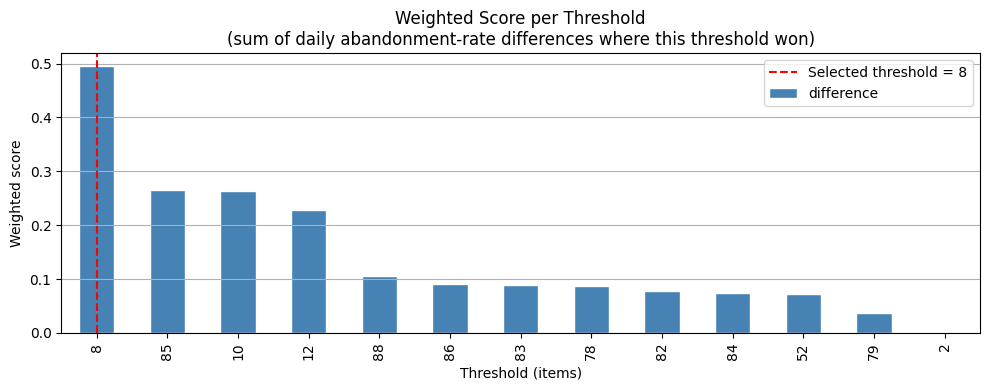


Mean daily abandonment rate per basket group:


,basket_group,mean_daily_abandonment_rate,std,days_observed
0,Large basket (>=8 items),0.059586,0.026472,15
1,Small basket (<8 items),0.064815,0.129389,12


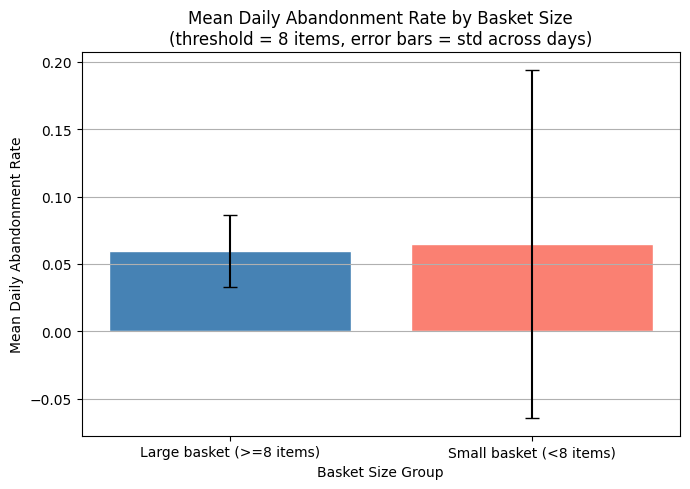

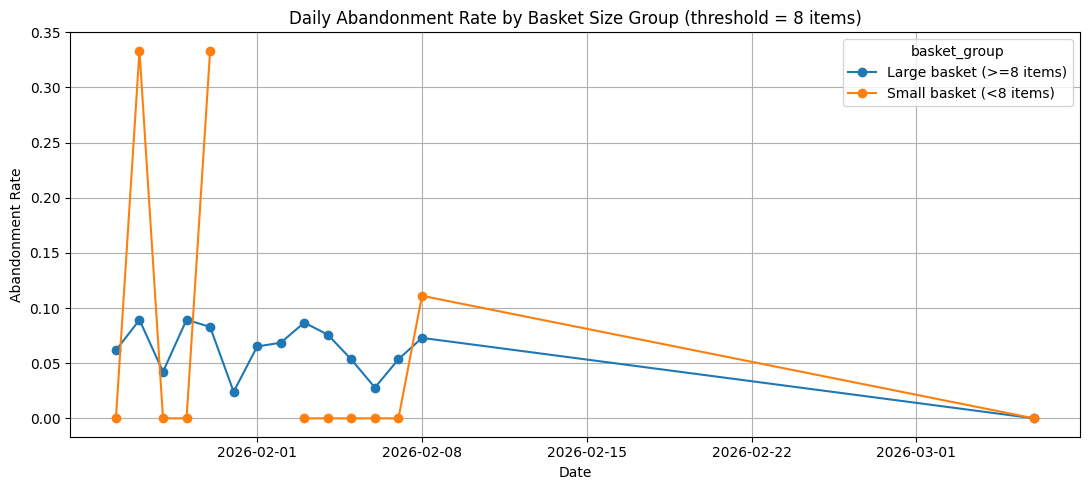

In [ ]:
# Build the items-per-customer table with dates
items_per_customer = (
    customer_df
    .groupby('case:concept:name')['items']
    .max()
    .reset_index()
    .rename(columns={'case:concept:name': 'customer_id'})
)

abandoned_customers = customer_df[
    customer_df['concept:name'] == 'Abandon cart and leave'
]['case:concept:name'].unique()

items_per_customer['abandoned'] = items_per_customer['customer_id'].isin(abandoned_customers)

customer_dates = (
    customer_df
    .groupby('case:concept:name')['time:timestamp']
    .min()
    .reset_index()
    .rename(columns={'case:concept:name': 'customer_id', 'time:timestamp': 'date'})
)
customer_dates['date'] = customer_dates['date'].dt.date
items_per_customer = items_per_customer.merge(customer_dates, on='customer_id')

# Determine candidate range from data
item_min = int(items_per_customer['items'].min())
item_max = int(items_per_customer['items'].max())
MIN_GROUP_SIZE = 3

print(f"Item range in data: {item_min} to {item_max}")
print(f"Searching all thresholds from {item_min + 1} to {item_max - 1}...\n")

# Find best threshold per day (weighted scoring)

daily_best_thresholds = []

for day, day_df in items_per_customer.groupby('date'):
    day_results = []
    for t in range(item_min + 1, item_max):
        small = day_df[day_df['items'] < t]
        large = day_df[day_df['items'] >= t]

        if len(small) < MIN_GROUP_SIZE or len(large) < MIN_GROUP_SIZE:
            continue

        rate_small = small['abandoned'].mean()
        rate_large = large['abandoned'].mean()
        diff = abs(rate_small - rate_large)

        day_results.append({'threshold': t, 'difference': diff})

    if day_results:
        best = max(day_results, key=lambda x: x['difference'])
        daily_best_thresholds.append({
            'date': day,
            'best_threshold': best['threshold'],
            'difference': best['difference']  
        })

daily_threshold_df = pd.DataFrame(daily_best_thresholds)

print("Best threshold per day:")
display(daily_threshold_df)

# Weighted vote
weighted_scores = (
    daily_threshold_df
    .groupby('best_threshold')['difference']
    .sum()
    .sort_values(ascending=False)
)

print("\nWeighted scores per threshold (sum of daily signal strengths):")
print(weighted_scores.to_string())

SMALL_BASKET_THRESHOLD = int(weighted_scores.idxmax())
print(f"\nFinal threshold (highest weighted score): {SMALL_BASKET_THRESHOLD} items")
print(f"  Days where this threshold won: {(daily_threshold_df['best_threshold'] == SMALL_BASKET_THRESHOLD).sum()}")
print(f"  Total days analysed          : {len(daily_threshold_df)}")

# Plot weighted scores
plt.figure(figsize=(10, 4))
weighted_scores.plot(kind='bar', color='steelblue', edgecolor='white')
plt.axvline(
    weighted_scores.index.tolist().index(SMALL_BASKET_THRESHOLD),
    color='red', linestyle='--', label=f'Selected threshold = {SMALL_BASKET_THRESHOLD}'
)
plt.title("Weighted Score per Threshold\n(sum of daily abandonment-rate differences where this threshold won)")
plt.xlabel("Threshold (items)")
plt.ylabel("Weighted score")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Apply the final threshold
items_per_customer['basket_group'] = np.where(
    items_per_customer['items'] < SMALL_BASKET_THRESHOLD,
    f'Small basket (<{SMALL_BASKET_THRESHOLD} items)',
    f'Large basket (>={SMALL_BASKET_THRESHOLD} items)'
)

# Daily abandonment rate per group
daily_abandonment = (
    items_per_customer
    .groupby(['date', 'basket_group'])
    .agg(
        total_customers=('customer_id', 'nunique'),
        abandoned_customers=('abandoned', 'sum'),
    )
    .reset_index()
)
daily_abandonment['abandonment_rate'] = (
    daily_abandonment['abandoned_customers'] / daily_abandonment['total_customers']
)

# Summary table
daily_summary = (
    daily_abandonment
    .groupby('basket_group')
    .agg(
        mean_daily_abandonment_rate=('abandonment_rate', 'mean'),
        std=('abandonment_rate', 'std'),
        days_observed=('date', 'nunique'),
    )
    .reset_index()
)
print("\nMean daily abandonment rate per basket group:")
display(daily_summary)

# Bar chart
plt.figure(figsize=(7, 5))
plt.bar(
    daily_summary['basket_group'],
    daily_summary['mean_daily_abandonment_rate'],
    yerr=daily_summary['std'],
    capsize=5, color=['steelblue', 'salmon'], edgecolor='white'
)
plt.title(f"Mean Daily Abandonment Rate by Basket Size\n(threshold = {SMALL_BASKET_THRESHOLD} items, error bars = std across days)")
plt.xlabel("Basket Size Group")
plt.ylabel("Mean Daily Abandonment Rate")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Daily trend line plot
pivot = daily_abandonment.pivot(index='date', columns='basket_group', values='abandonment_rate')
pivot.plot(figsize=(11, 5), marker='o')
plt.title(f"Daily Abandonment Rate by Basket Size Group (threshold = {SMALL_BASKET_THRESHOLD} items)")
plt.xlabel("Date")
plt.ylabel("Abandonment Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

Item distribution — abandoned vs. completed:
            count   mean    std  min   25%   50%   75%   max
abandoned                                                   
False      8969.0  61.93  15.43  1.0  58.0  64.0  71.0  97.0
True        588.0  63.38  12.68  2.0  59.0  65.0  71.0  89.0

Mann-Whitney U test (abandoned vs completed basket size):
  U = 2704864,  p = 0.2940
  Mean items — abandoned : 63.38
  Mean items — completed : 61.93
  → No statistically significant difference in basket size
  → The data does not support this hypothesis


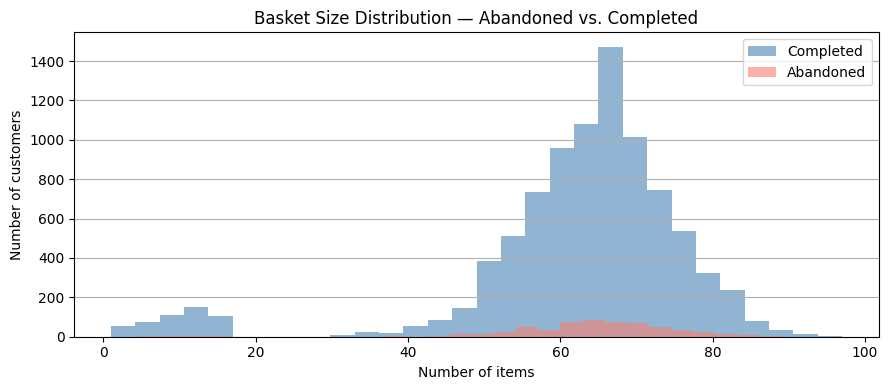


Abandonment rate by item decile:


,item_decile,abandonment_rate,n_customers
0,"(0.999, 50.0]",0.046332,1036
1,"(50.0, 56.0]",0.054890,1002
2,"(56.0, 59.0]",0.064294,871
3,"(59.0, 62.0]",0.066789,1093
4,"(62.0, 64.0]",0.070064,785
5,"(64.0, 67.0]",0.071249,1193
6,"(67.0, 69.0]",0.060367,762
7,"(69.0, 72.0]",0.060939,1001
8,"(72.0, 76.0]",0.061555,926
9,"(76.0, 97.0]",0.058559,888


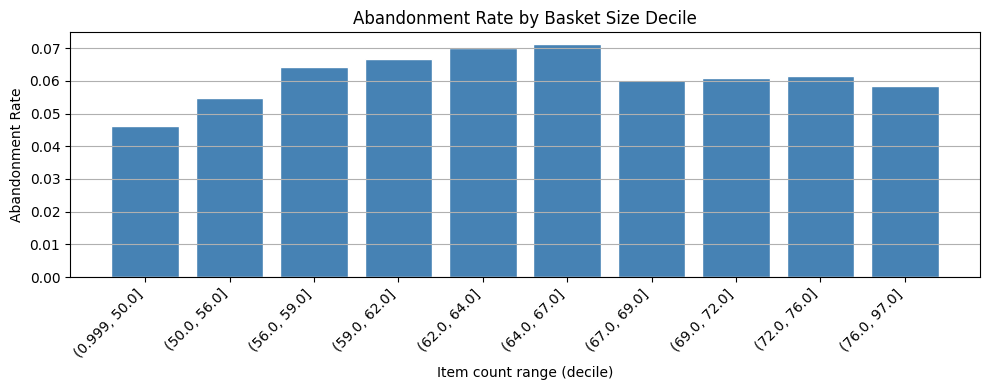

In [ ]:
# Build the items-per-customer table
items_per_customer = (
    customer_df
    .groupby('case:concept:name')['items']
    .max()
    .reset_index()
    .rename(columns={'case:concept:name': 'customer_id'})
)

abandoned_customers = customer_df[
    customer_df['concept:name'] == 'Abandon cart and leave'
]['case:concept:name'].unique()

items_per_customer['abandoned'] = items_per_customer['customer_id'].isin(abandoned_customers)

print("Item distribution — abandoned vs. completed:")
print(items_per_customer.groupby('abandoned')['items'].describe().round(2))

from scipy import stats

abandoned_items  = items_per_customer[items_per_customer['abandoned']]['items']
completed_items  = items_per_customer[~items_per_customer['abandoned']]['items']

stat, p = stats.mannwhitneyu(abandoned_items, completed_items, alternative='two-sided')
print(f"\nMann-Whitney U test (abandoned vs completed basket size):")
print(f"  U = {stat:.0f},  p = {p:.4f}")
print(f"  Mean items — abandoned : {abandoned_items.mean():.2f}")
print(f"  Mean items — completed : {completed_items.mean():.2f}")
if p < 0.05:
    print("  → Statistically significant difference in basket size")
else:
    print("  → No statistically significant difference in basket size")
    print("  → The data does not support this hypothesis")

# Distribution plot
plt.figure(figsize=(9, 4))
plt.hist(completed_items, bins=30, alpha=0.6, label='Completed', color='steelblue')
plt.hist(abandoned_items,  bins=30, alpha=0.6, label='Abandoned',  color='salmon')
plt.title("Basket Size Distribution — Abandoned vs. Completed")
plt.xlabel("Number of items")
plt.ylabel("Number of customers")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Abandonment rate by item decile
items_per_customer['item_decile'] = pd.qcut(
    items_per_customer['items'], q=10, duplicates='drop'
)
decile_summary = (
    items_per_customer
    .groupby('item_decile', observed=True)['abandoned']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'abandonment_rate', 'count': 'n_customers'})
)

print("\nAbandonment rate by item decile:")
display(decile_summary)

plt.figure(figsize=(10, 4))
plt.bar(range(len(decile_summary)), decile_summary['abandonment_rate'], color='steelblue', edgecolor='white')
plt.xticks(range(len(decile_summary)),
           [str(i) for i in decile_summary['item_decile']], rotation=45, ha='right')
plt.title("Abandonment Rate by Basket Size Decile")
plt.xlabel("Item count range (decile)")
plt.ylabel("Abandonment Rate")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

── H1: Basket size vs abandonment ───────────────────────────
  Mean basket size — abandoned : 45.52
  Mean basket size — completed : 44.49
  Mann-Whitney U = 2703402,  p = 0.3046

  → Not statistically significant (p = 0.305)
  → NOTE: 'items' is a fixed customer profile attribute, not a
    per-visit basket size. This hypothesis cannot be properly
    tested with the available data.


C:\Users\Sujitha\AppData\Local\Temp\ipykernel_37232\3914436793.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


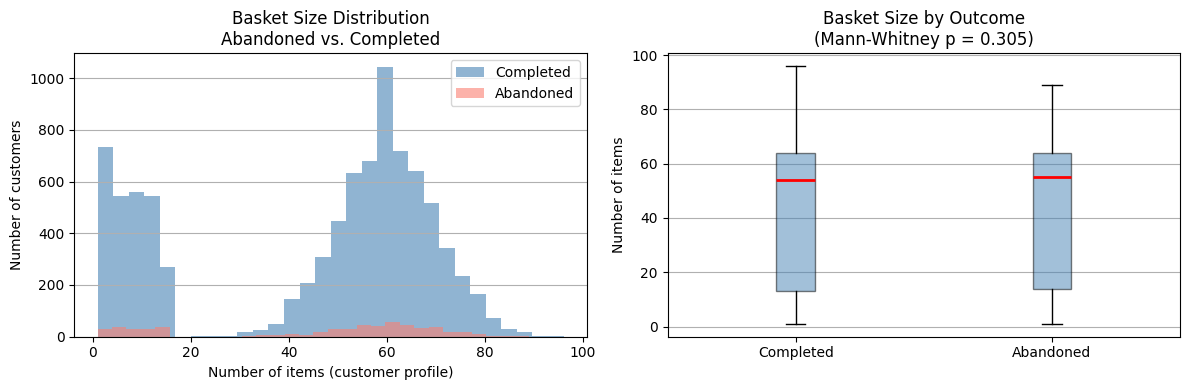

In [ ]:
items_per_customer = (
    customer_df
    .groupby('case:concept:name')['items']
    .first()  
    .reset_index()
    .rename(columns={'case:concept:name': 'customer_id', 'items': 'basket_size'})
)

abandoned_customers = customer_df[
    customer_df['concept:name'] == 'Abandon cart and leave'
]['case:concept:name'].unique()

items_per_customer['abandoned'] = items_per_customer['customer_id'].isin(abandoned_customers)

abandoned_items  = items_per_customer[items_per_customer['abandoned']]['basket_size']
completed_items  = items_per_customer[~items_per_customer['abandoned']]['basket_size']

from scipy import stats
stat, p = stats.mannwhitneyu(abandoned_items, completed_items, alternative='two-sided')

print("── H1: Basket size vs abandonment ───────────────────────────")
print(f"  Mean basket size — abandoned : {abandoned_items.mean():.2f}")
print(f"  Mean basket size — completed : {completed_items.mean():.2f}")
print(f"  Mann-Whitney U = {stat:.0f},  p = {p:.4f}")
print()
if p < 0.05:
    print("  → Statistically significant: basket size differs between groups")
else:
    print("  → Not statistically significant (p = {:.3f})".format(p))
    print("  → NOTE: 'items' is a fixed customer profile attribute, not a")
    print("    per-visit basket size. This hypothesis cannot be properly")
    print("    tested with the available data.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(completed_items, bins=30, alpha=0.6, label='Completed', color='steelblue')
axes[0].hist(abandoned_items,  bins=30, alpha=0.6, label='Abandoned',  color='salmon')
axes[0].set_title("Basket Size Distribution\nAbandoned vs. Completed")
axes[0].set_xlabel("Number of items (customer profile)")
axes[0].set_ylabel("Number of customers")
axes[0].legend()
axes[0].grid(axis='y')

axes[1].boxplot(
    [completed_items, abandoned_items],
    labels=['Completed', 'Abandoned'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.5),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title(f"Basket Size by Outcome\n(Mann-Whitney p = {p:.3f})")
axes[1].set_ylabel("Number of items")
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

### H1 sub-part: Basket size and waiting time

Rows after merge: 25325
Missing basket_size: 0

── Continuous relationship: basket size vs waiting time ──
  Pearson  r   = 0.1616,  p = 0.0000
  Spearman rho = 0.2173,  p = 0.0000


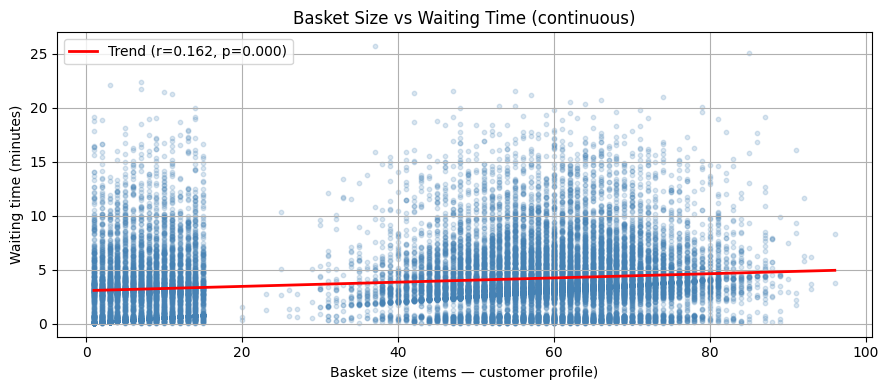


Waiting time by basket size decile:


,basket_decile,mean,median,count
0,"(0.999, 5.0]",3.043702,2.744400,2574
1,"(5.0, 10.0]",3.292759,2.891217,2595
2,"(10.0, 35.0]",3.337131,2.806117,2434
3,"(35.0, 50.0]",4.065460,3.232217,2840
4,"(50.0, 54.0]",4.006571,3.262283,2239
5,"(54.0, 58.0]",4.158485,3.306983,2614
6,"(58.0, 62.0]",4.259189,3.348533,2940
7,"(62.0, 66.0]",4.301004,3.452033,2527
8,"(66.0, 70.0]",4.336048,3.560225,2086
9,"(70.0, 96.0]",4.577895,3.858050,2476


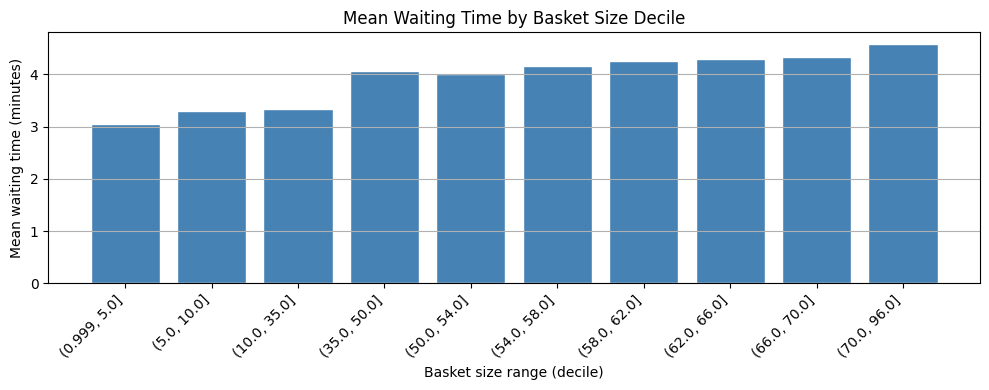


Express lane threshold search range: 2 to 13 items

Best express lane threshold per day:


,threshold,mean_wait_small,mean_wait_large,difference,n_small,n_large,date
0,12,1.290737,3.920152,2.629415,157,481,2026-01-26
1,13,1.281232,4.315792,3.034560,171,539,2026-01-27
2,10,3.005687,5.671584,2.665898,129,617,2026-01-28
3,2,0.754874,3.959554,3.204680,12,721,2026-01-29
4,6,1.318275,4.174516,2.856241,76,606,2026-01-30
5,4,0.644207,3.643536,2.999329,29,425,2026-01-31
6,2,0.313339,3.976823,3.663484,9,434,2026-02-01
7,13,1.448460,4.302353,2.853894,171,514,2026-02-02
8,9,1.048668,3.958130,2.909463,116,607,2026-02-03
9,5,1.487316,4.729176,3.241860,61,685,2026-02-04



Data-driven express lane threshold: < 2 items

Waiting time summary by basket group:


,count,mean,median,std
basket_group,,,,
Large basket (>=2 items),24839,3.949,3.342,3.052
Small basket (<2 items),486,3.224,2.770,3.467



Mann-Whitney U test (waiting time: small vs large basket):
  U = 4711436,  p = 0.0000
  → Significant difference in waiting time


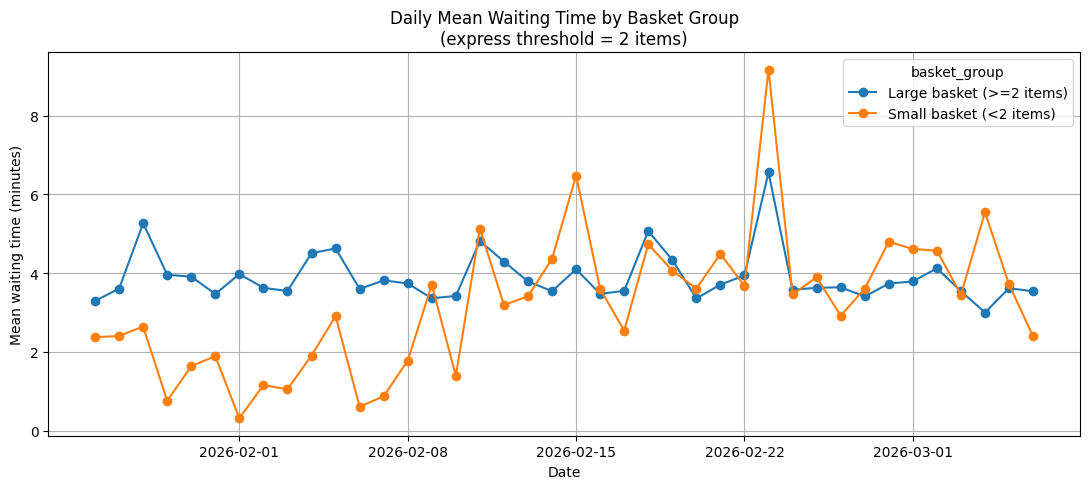

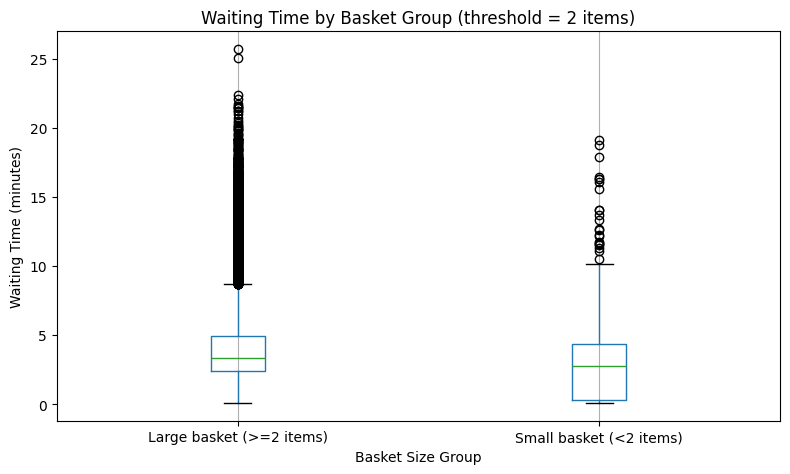

In [ ]:
from scipy import stats

# Build items_per_customer
items_per_customer = (
    customer_df
    .groupby('case:concept:name')['items']
    .first()
    .reset_index()
    .rename(columns={'case:concept:name': 'customer_id', 'items': 'basket_size'})
)

abandoned_customers = customer_df[
    customer_df['concept:name'] == 'Abandon cart and leave'
]['case:concept:name'].unique()
items_per_customer['abandoned'] = items_per_customer['customer_id'].isin(abandoned_customers)

# Merge waiting times with basket size
waiting_with_items = waiting_df.merge(items_per_customer, on='customer_id', how='left')

print(f"Rows after merge: {len(waiting_with_items)}")
print(f"Missing basket_size: {waiting_with_items['basket_size'].isna().sum()}")

clean = waiting_with_items.dropna(subset=['basket_size', 'waiting_minutes'])

r, p = stats.pearsonr(clean['basket_size'], clean['waiting_minutes'])
rho, p_spear = stats.spearmanr(clean['basket_size'], clean['waiting_minutes'])

print(f"\n── Continuous relationship: basket size vs waiting time ──")
print(f"  Pearson  r   = {r:.4f},  p = {p:.4f}")
print(f"  Spearman rho = {rho:.4f},  p = {p_spear:.4f}")

# Scatter with trend line
plt.figure(figsize=(9, 4))
plt.scatter(clean['basket_size'], clean['waiting_minutes'],
            alpha=0.2, color='steelblue', s=10)
m, b = np.polyfit(clean['basket_size'], clean['waiting_minutes'], 1)
x_line = np.linspace(clean['basket_size'].min(), clean['basket_size'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2,
         label=f'Trend (r={r:.3f}, p={p:.3f})')
plt.title("Basket Size vs Waiting Time (continuous)")
plt.xlabel("Basket size (items — customer profile)")
plt.ylabel("Waiting time (minutes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

clean['basket_decile'] = pd.qcut(clean['basket_size'], q=10, duplicates='drop')
decile_wait = (
    clean
    .groupby('basket_decile', observed=True)['waiting_minutes']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)
print("\nWaiting time by basket size decile:")
display(decile_wait)

plt.figure(figsize=(10, 4))
plt.bar(range(len(decile_wait)), decile_wait['mean'], color='steelblue', edgecolor='white')
plt.xticks(range(len(decile_wait)),
           [str(d) for d in decile_wait['basket_decile']], rotation=45, ha='right')
plt.title("Mean Waiting Time by Basket Size Decile")
plt.xlabel("Basket size range (decile)")
plt.ylabel("Mean waiting time (minutes)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Find threshold day by day
waiting_with_items['date'] = pd.to_datetime(
    waiting_with_items['enter_queue_time']
).dt.date

MAX_THRESHOLD = int(clean['basket_size'].quantile(0.25))
print(f"\nExpress lane threshold search range: 2 to {MAX_THRESHOLD} items")

daily_threshold_results = []

for day, day_df in waiting_with_items.dropna(subset=['basket_size']).groupby('date'):
    day_results = []
    for t in range(2, MAX_THRESHOLD + 1):
        small = day_df[day_df['basket_size'] < t]['waiting_minutes'].dropna()
        large = day_df[day_df['basket_size'] >= t]['waiting_minutes'].dropna()

        if len(small) < 3 or len(large) < 3:
            continue

        diff = abs(small.mean() - large.mean())
        day_results.append({
            'threshold': t,
            'mean_wait_small': small.mean(),
            'mean_wait_large': large.mean(),
            'difference': diff,
            'n_small': len(small),
            'n_large': len(large),
        })

    if day_results:
        best = max(day_results, key=lambda x: x['difference'])
        best['date'] = day
        daily_threshold_results.append(best)

daily_express_df = pd.DataFrame(daily_threshold_results)

print("\nBest express lane threshold per day:")
display(daily_express_df)

# Weighted vote — threshold that accumulates most signal wins
weighted_scores = (
    daily_express_df
    .groupby('threshold')['difference']
    .sum()
    .sort_values(ascending=False)
)
EXPRESS_THRESHOLD = int(weighted_scores.idxmax())
print(f"\nData-driven express lane threshold: < {EXPRESS_THRESHOLD} items")

# Apply express threshold and compare waiting times
waiting_with_items['basket_group'] = np.where(
    waiting_with_items['basket_size'] < EXPRESS_THRESHOLD,
    f'Small basket (<{EXPRESS_THRESHOLD} items)',
    f'Large basket (>={EXPRESS_THRESHOLD} items)'
)

# Overall summary
wait_basket_summary = (
    waiting_with_items
    .groupby('basket_group')['waiting_minutes']
    .agg(['count', 'mean', 'median', 'std'])
    .round(3)
)
print("\nWaiting time summary by basket group:")
display(wait_basket_summary)

# Mann-Whitney test on waiting times
small_wait = waiting_with_items[
    waiting_with_items['basket_size'] < EXPRESS_THRESHOLD
]['waiting_minutes'].dropna()
large_wait = waiting_with_items[
    waiting_with_items['basket_size'] >= EXPRESS_THRESHOLD
]['waiting_minutes'].dropna()

stat, p = stats.mannwhitneyu(small_wait, large_wait, alternative='two-sided')
print(f"\nMann-Whitney U test (waiting time: small vs large basket):")
print(f"  U = {stat:.0f},  p = {p:.4f}")
print("  → Significant difference in waiting time" if p < 0.05
      else "  → No significant difference in waiting time")

# Daily comparison plot
daily_wait_group = (
    waiting_with_items
    .groupby(['date', 'basket_group'])['waiting_minutes']
    .mean()
    .reset_index()
)

pivot = daily_wait_group.pivot(
    index='date', columns='basket_group', values='waiting_minutes'
)
pivot.plot(figsize=(11, 5), marker='o')
plt.title(f"Daily Mean Waiting Time by Basket Group\n(express threshold = {EXPRESS_THRESHOLD} items)")
plt.xlabel("Date")
plt.ylabel("Mean waiting time (minutes)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Box plot
waiting_with_items.boxplot(
    column='waiting_minutes', by='basket_group', figsize=(8, 5)
)
plt.title(f"Waiting Time by Basket Group (threshold = {EXPRESS_THRESHOLD} items)")
plt.suptitle("")
plt.xlabel("Basket Size Group")
plt.ylabel("Waiting Time (minutes)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## H2. Payment method affects checkout duration

,count,mean,std,min,25%,50%,75%,max
payment_method,,,,,,,,
Cash,5916.0,0.447641,0.147272,0.0000,0.348692,0.447017,0.548204,0.990033
Pin,19409.0,0.948890,0.170835,0.3067,0.833250,0.949200,1.064900,1.632317


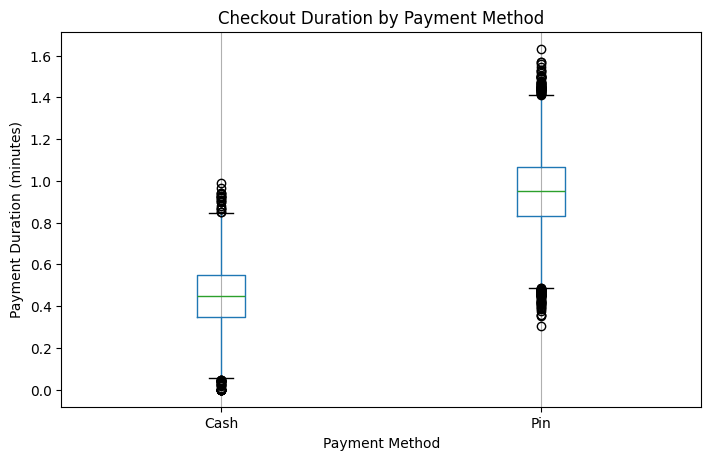

In [13]:
display(payment_duration_df.groupby('payment_method')['payment_duration_minutes'].describe())

payment_duration_df.boxplot(
    column='payment_duration_minutes',
    by='payment_method',
    figsize=(8,5)
)

plt.title("Checkout Duration by Payment Method")
plt.suptitle("")
plt.xlabel("Payment Method")
plt.ylabel("Payment Duration (minutes)")
plt.grid(axis='y')
plt.show()


### H2 optional: Average payment duration by hour and method

── Payment duration by method ───────────────────────────────


,count,mean,std,min,25%,50%,75%,max
payment_method,,,,,,,,
Cash,5916.0,0.448,0.147,0.000,0.349,0.447,0.548,0.990
Pin,19409.0,0.949,0.171,0.307,0.833,0.949,1.065,1.632


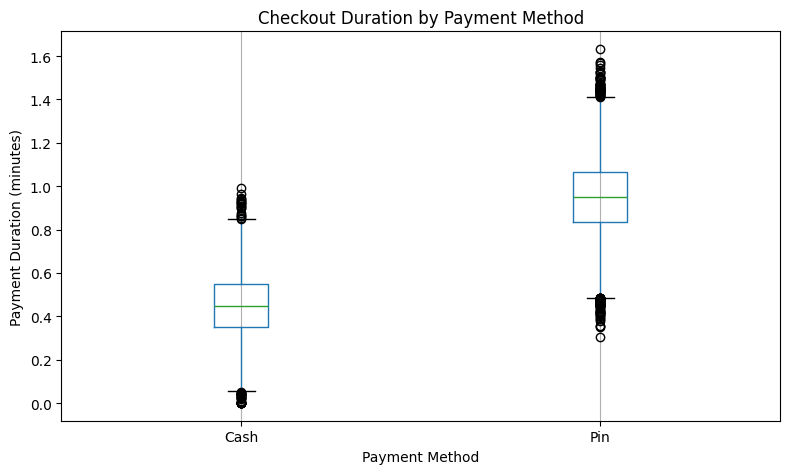


Kruskal-Wallis test across all payment methods: H=12907.450, p=0.0000
→ Significant difference between methods

Pairwise comparison: Pin vs each other method (Mann-Whitney U)
  Pin vs Cash      : U=113339729, p=0.0000 *  |  Pin mean=0.949, Cash mean=0.448  → Pin SLOWER


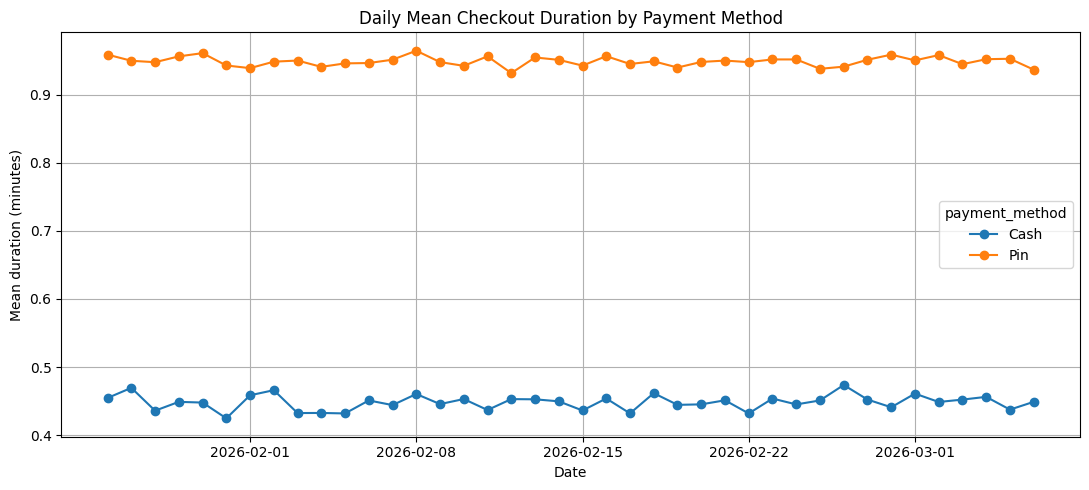


Days where each method had the longest mean duration:
Pin    40

Queue payment composition table: 9554 rows

── Correlation with waiting time ────────────────────────────
  Total customers ahead         : r = +0.4125, p = 0.0000 *
  Pin payers ahead (count)      : r = +0.3982,   p = 0.0000 *
  Pin payers ahead (% of queue) : r = +0.0041, p = 0.6872


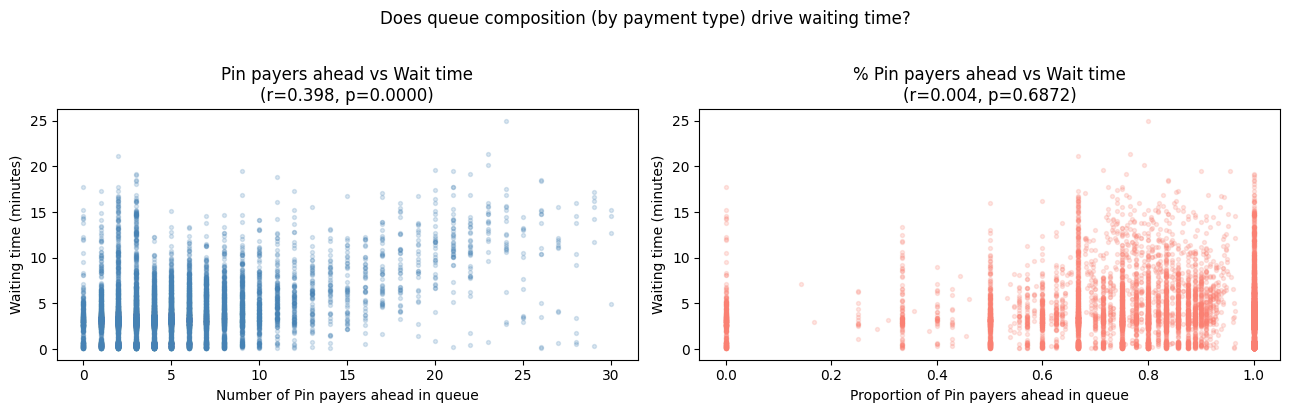


── Own payment duration vs own waiting time ─────────────────
  Pearson r = 0.0539, p = 0.0000 *
  (Low correlation expected — your wait depends on others, not yourself)

Mean payment duration and mean waiting time by method:


,payment_duration_minutes,waiting_minutes
payment_method,,
Cash,0.447,3.563
Pin,0.949,4.081


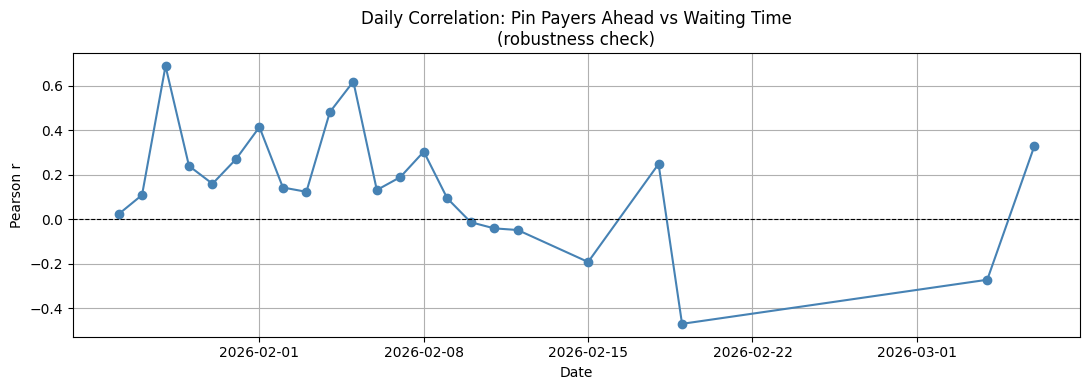


Days where more Pin payers ahead → longer wait: 74% of days
→ Consistent positive effect


In [ ]:
from scipy import stats

# Basic summary
print("Payment duration by method")
display(payment_duration_df.groupby('payment_method')['payment_duration_minutes'].describe().round(3))

payment_duration_df.boxplot(
    column='payment_duration_minutes',
    by='payment_method',
    figsize=(8, 5)
)
plt.title("Checkout Duration by Payment Method")
plt.suptitle("")
plt.xlabel("Payment Method")
plt.ylabel("Payment Duration (minutes)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

methods = payment_duration_df['payment_method'].dropna().unique()
groups  = [
    payment_duration_df[payment_duration_df['payment_method'] == m]['payment_duration_minutes'].dropna()
    for m in methods
]

# Kruskal-Wallis across all methods
stat, p = stats.kruskal(*groups)
print(f"\nKruskal-Wallis test across all payment methods: H={stat:.3f}, p={p:.4f}")
print("→ Significant difference between methods" if p < 0.05 else "→ No significant difference")

# Pairwise Mann-Whitney: Pin vs each other method
if 'Pin' in methods:
    pin_durations = payment_duration_df[
        payment_duration_df['payment_method'] == 'Pin'
    ]['payment_duration_minutes'].dropna()

    print("\nPairwise comparison: Pin vs each other method (Mann-Whitney U)")
    for m in methods:
        if m == 'Pin':
            continue
        other = payment_duration_df[
            payment_duration_df['payment_method'] == m
        ]['payment_duration_minutes'].dropna()
        u, p_val = stats.mannwhitneyu(pin_durations, other, alternative='two-sided')
        direction = "Pin SLOWER" if pin_durations.mean() > other.mean() else "Pin FASTER"
        sig = "*" if p_val < 0.05 else ""
        print(f"  Pin vs {m:<10}: U={u:.0f}, p={p_val:.4f} {sig}  |  "
              f"Pin mean={pin_durations.mean():.3f}, {m} mean={other.mean():.3f}  → {direction}")

payment_duration_df['date'] = pd.to_datetime(
    payment_duration_df['start_payment_time']
).dt.date

daily_payment = (
    payment_duration_df
    .groupby(['date', 'payment_method'])['payment_duration_minutes']
    .mean()
    .reset_index()
)

pivot_daily = daily_payment.pivot(
    index='date', columns='payment_method', values='payment_duration_minutes'
)

pivot_daily.plot(figsize=(11, 5), marker='o')
plt.title("Daily Mean Checkout Duration by Payment Method")
plt.xlabel("Date")
plt.ylabel("Mean duration (minutes)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Count how many days each method is the slowest
slowest_per_day = pivot_daily.idxmax(axis=1)
print("\nDays where each method had the longest mean duration:")
print(slowest_per_day.value_counts().to_string())

payment_method_lookup = (
    payment_duration_df
    .groupby('customer_id')['payment_method']
    .first()
)

queue_timeline['payment_method'] = queue_timeline['customer_id'].map(payment_method_lookup)

rows = []
queue_sorted = queue_timeline.sort_values('enter_queue_time')

for _, focal in queue_sorted.iterrows():
    ahead = queue_sorted[
        (queue_sorted['enter_queue_time'] < focal['enter_queue_time']) &
        (queue_sorted['exit_queue_time']  > focal['enter_queue_time']) &
        (queue_sorted['customer_id']      != focal['customer_id'])
    ]

    wait_min = (
        focal['exit_queue_time'] - focal['enter_queue_time']
    ).total_seconds() / 60

    n_ahead     = len(ahead)
    n_pin_ahead = (ahead['payment_method'] == 'Pin').sum() if len(ahead) > 0 else 0
    pct_pin     = n_pin_ahead / n_ahead if n_ahead > 0 else 0

    rows.append({
        'customer_id':    focal['customer_id'],
        'waiting_minutes': wait_min,
        'n_ahead':        n_ahead,
        'n_pin_ahead':    n_pin_ahead,
        'pct_pin_ahead':  pct_pin,
        'focal_method':   focal['payment_method'],
        'date':           focal['enter_queue_time'].date(),
    })

queue_payment_df = pd.DataFrame(rows)
print(f"\nQueue payment composition table: {len(queue_payment_df)} rows")

# Does having more Pin payers ahead increase your wait time
clean_qp = queue_payment_df.dropna(subset=['waiting_minutes'])

r_n,   p_n   = stats.pearsonr(clean_qp['n_pin_ahead'],    clean_qp['waiting_minutes'])
r_pct, p_pct = stats.pearsonr(clean_qp['pct_pin_ahead'],  clean_qp['waiting_minutes'])
r_tot, p_tot = stats.pearsonr(clean_qp['n_ahead'],         clean_qp['waiting_minutes'])

print("\n Correlation with waiting time")
print(f"  Total customers ahead         : r = {r_tot:+.4f}, p = {p_tot:.4f}"
      + (" *" if p_tot < 0.05 else ""))
print(f"  Pin payers ahead (count)      : r = {r_n:+.4f},   p = {p_n:.4f}"
      + (" *" if p_n < 0.05 else ""))
print(f"  Pin payers ahead (% of queue) : r = {r_pct:+.4f}, p = {p_pct:.4f}"
      + (" *" if p_pct < 0.05 else ""))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(clean_qp['n_pin_ahead'], clean_qp['waiting_minutes'],
                alpha=0.2, s=8, color='steelblue')
axes[0].set_title(f"Pin payers ahead vs Wait time\n(r={r_n:.3f}, p={p_n:.4f})")
axes[0].set_xlabel("Number of Pin payers ahead in queue")
axes[0].set_ylabel("Waiting time (minutes)")

axes[1].scatter(clean_qp['pct_pin_ahead'], clean_qp['waiting_minutes'],
                alpha=0.2, s=8, color='salmon')
axes[1].set_title(f"% Pin payers ahead vs Wait time\n(r={r_pct:.3f}, p={p_pct:.4f})")
axes[1].set_xlabel("Proportion of Pin payers ahead in queue")
axes[1].set_ylabel("Waiting time (minutes)")

plt.suptitle("Does queue composition (by payment type) drive waiting time?", y=1.02)
plt.tight_layout()
plt.show()

pay_wait = payment_duration_df.merge(
    waiting_df[['customer_id', 'waiting_minutes']],
    on='customer_id', how='inner'
)

r_pw, p_pw = stats.pearsonr(
    pay_wait['payment_duration_minutes'],
    pay_wait['waiting_minutes']
)
print(f"\n── Own payment duration vs own waiting time ─────────────────")
print(f"  Pearson r = {r_pw:.4f}, p = {p_pw:.4f}"
      + (" *" if p_pw < 0.05 else ""))
print("  (Low correlation expected — your wait depends on others, not yourself)")

pay_wait_summary = (
    pay_wait
    .groupby('payment_method')[['payment_duration_minutes', 'waiting_minutes']]
    .mean()
    .round(3)
)
print("\nMean payment duration and mean waiting time by method:")
display(pay_wait_summary)

daily_corr_pay = []
for day, day_df in clean_qp.groupby('date'):
    if len(day_df) < 10:
        continue
    r, p_val = stats.pearsonr(day_df['n_pin_ahead'], day_df['waiting_minutes'])
    daily_corr_pay.append({'date': day, 'r_pin_ahead_vs_wait': r, 'p': p_val})

daily_corr_pay_df = pd.DataFrame(daily_corr_pay)

daily_corr_pay_df.set_index('date')['r_pin_ahead_vs_wait'].plot(
    figsize=(11, 4), marker='o', color='steelblue'
)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Daily Correlation: Pin Payers Ahead vs Waiting Time\n(robustness check)")
plt.ylabel("Pearson r")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

pct_positive = (daily_corr_pay_df['r_pin_ahead_vs_wait'] > 0).mean() * 100
print(f"\nDays where more Pin payers ahead → longer wait: {pct_positive:.0f}% of days")
print("→ Consistent positive effect" if pct_positive >= 70
      else "→ Effect is not consistent across days")

payment_method,Cash,Pin
hour,,
14,0.462242,0.929808
15,0.452191,0.943624
16,0.451581,0.957725
17,0.448329,0.945002
18,0.445350,0.948283
19,0.444268,0.946069
20,0.444081,0.950186
21,0.447640,0.954556
22,0.475546,0.965440


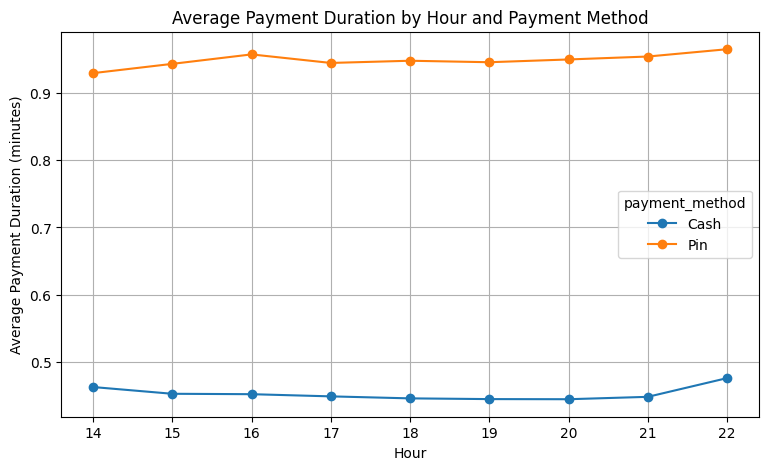

In [15]:
payment_hour_method = (
    payment_duration_df
    .groupby(['hour', 'payment_method'])['payment_duration_minutes']
    .mean()
    .unstack()
)

display(payment_hour_method)

payment_hour_method.plot(figsize=(9,5), marker='o')
plt.title("Average Payment Duration by Hour and Payment Method")
plt.xlabel("Hour")
plt.ylabel("Average Payment Duration (minutes)")
plt.grid(True)
plt.show()


## H3. Manager absence and abandonment / waiting time

C:\Users\Sujitha\AppData\Local\Temp\ipykernel_37232\2048990934.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }).fillna({'manager_present': False, 'abandonments': 0})


,manager_present,abandonments,avg_waiting_time,manager_status
hour,,,,
14,True,547.0,9.996775,Manager present
15,False,36.0,3.318811,No manager present
16,False,0.0,3.287809,No manager present
17,False,0.0,3.181635,No manager present
18,False,0.0,2.890585,No manager present
19,False,8.0,5.011283,No manager present
20,False,0.0,4.398416,No manager present
21,False,0.0,3.072988,No manager present
22,False,0.0,2.726486,No manager present


,abandonments,avg_waiting_time
manager_status,,
Manager present,547.0,9.996775
No manager present,5.5,3.486002


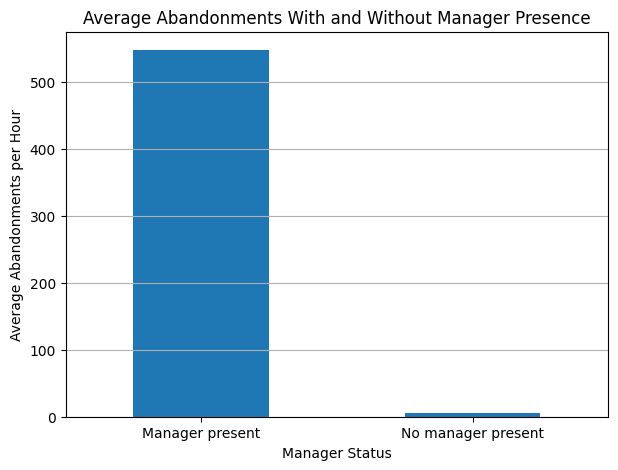

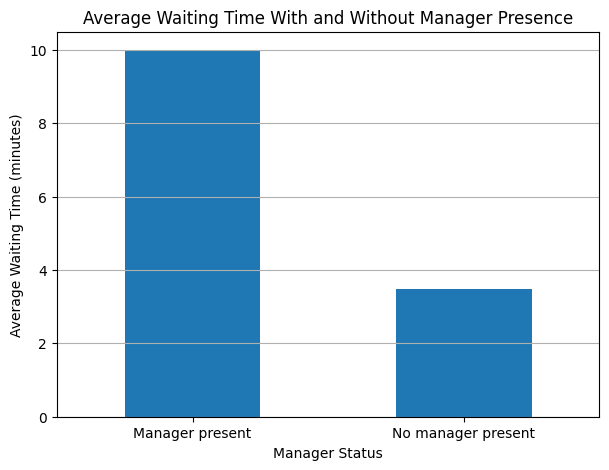

In [16]:
manager_presence_by_hour = manager_presence_df.groupby('hour')['manager_present'].max()

abandonment_events = customer_df[customer_df['concept:name'] == 'Abandon cart and leave'].copy()
abandonments_by_hour = abandonment_events.groupby('hour')['case:concept:name'].nunique()
waiting_by_hour = waiting_df.groupby('hour')['waiting_minutes'].mean()

manager_comparison = pd.DataFrame({
    'manager_present': manager_presence_by_hour,
    'abandonments': abandonments_by_hour,
    'avg_waiting_time': waiting_by_hour
}).fillna({'manager_present': False, 'abandonments': 0})

manager_comparison['manager_status'] = np.where(
    manager_comparison['manager_present'],
    'Manager present',
    'No manager present'
)

display(manager_comparison)
display(manager_comparison.groupby('manager_status')[['abandonments', 'avg_waiting_time']].mean())

manager_comparison.groupby('manager_status')['abandonments'].mean().plot(kind='bar', figsize=(7,5))
plt.title("Average Abandonments With and Without Manager Presence")
plt.xlabel("Manager Status")
plt.ylabel("Average Abandonments per Hour")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

manager_comparison.groupby('manager_status')['avg_waiting_time'].mean().plot(kind='bar', figsize=(7,5))
plt.title("Average Waiting Time With and Without Manager Presence")
plt.xlabel("Manager Status")
plt.ylabel("Average Waiting Time (minutes)")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


## H4. High arrivals do not necessarily cause congestion if capacity is sufficient

Date+hour observations: 320


,date,hour,arrivals,abandonments,avg_counters,avg_wait,abandonment_rate,arrival_to_counter_ratio
0,2026-01-26,14,37,12.0,1.000000,10.917751,0.324324,37.000000
1,2026-01-26,15,49,1.0,4.000000,2.670188,0.020408,12.250000
2,2026-01-26,16,82,0.0,8.000000,3.263439,0.000000,10.250000
3,2026-01-26,17,95,0.0,10.500000,2.813214,0.000000,9.047619
4,2026-01-26,18,104,0.0,12.333333,2.701320,0.000000,8.432432
5,2026-01-26,19,128,0.0,11.428571,3.212598,0.000000,11.200000
6,2026-01-26,20,107,0.0,10.500000,3.323709,0.000000,10.190476
7,2026-01-26,21,49,0.0,NaN,3.277579,0.000000,NaN
8,2026-01-27,14,47,20.0,1.000000,10.037828,0.425532,47.000000
9,2026-01-27,15,55,1.0,4.000000,3.277192,0.018182,13.750000



Hourly averages across all days:


,mean_arrivals,mean_counters,mean_wait,mean_abandon_rate,mean_ratio
hour,,,,,
14,38.625,1.000,10.115,0.360,38.625
15,54.300,3.750,3.278,0.017,14.369
16,94.200,7.312,3.284,0.000,12.824
17,89.975,9.506,3.133,0.000,9.411
18,92.550,10.958,2.879,0.000,8.402
19,124.000,9.427,4.717,0.001,13.067
20,104.075,7.922,4.372,0.000,13.303
21,51.150,NaN,3.043,0.000,NaN


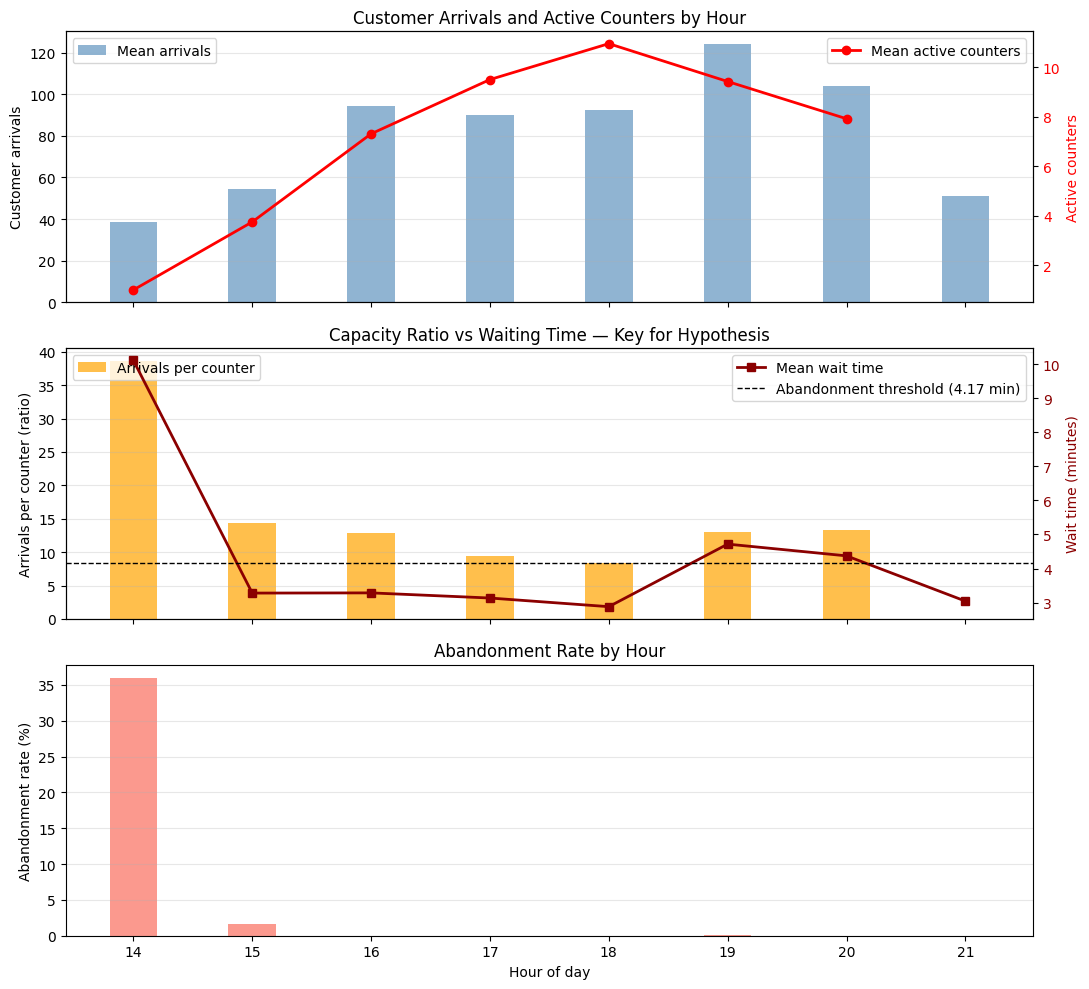


── What correlates with waiting time? ───────────────────────
  Customer arrivals                  : r = -0.3059, p = 0.0000 *
  Active counters                    : r = -0.6165, p = 0.0000 *
  Arrivals per counter (ratio)       : r = +0.8923, p = 0.0000 *

── What correlates with abandonment rate? ───────────────────
  Customer arrivals                  : r = -0.5216, p = 0.0000 *
  Active counters                    : r = -0.6907, p = 0.0000 *
  Arrivals per counter (ratio)       : r = +0.9468, p = 0.0000 *

The four scenarios — core of the hypothesis test:


,n,mean_wait,median_wait,mean_abandon_rate
scenario,,,,
High arrivals + Insufficient capacity,14,4.714,4.217,0.001
High arrivals + Sufficient capacity,142,3.670,3.268,0.000
Low arrivals + Insufficient capacity,152,5.072,3.350,0.099
Low arrivals + Sufficient capacity,12,2.896,2.875,0.000


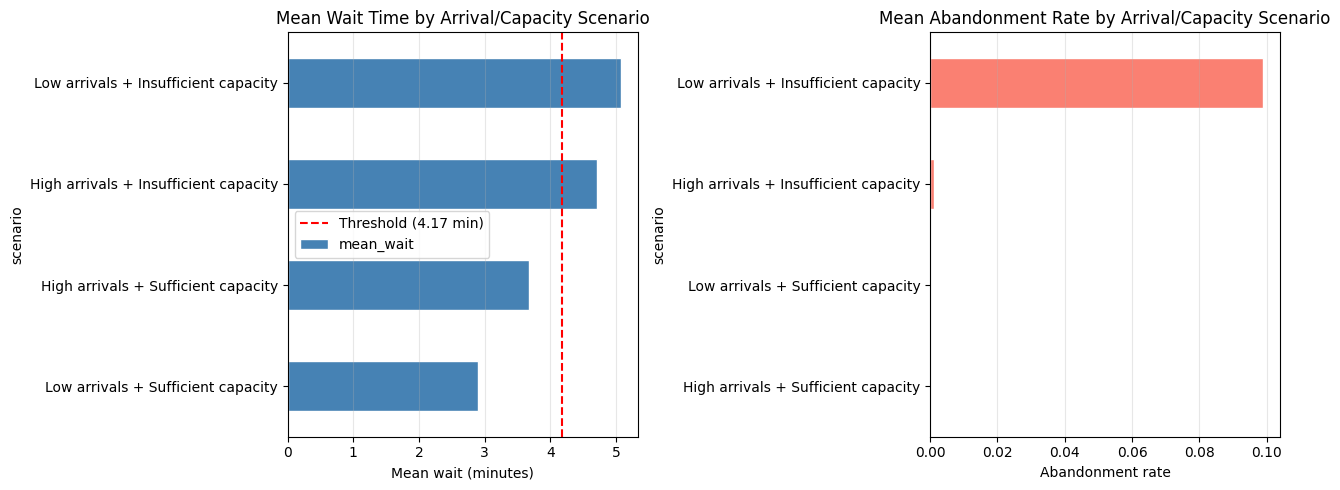

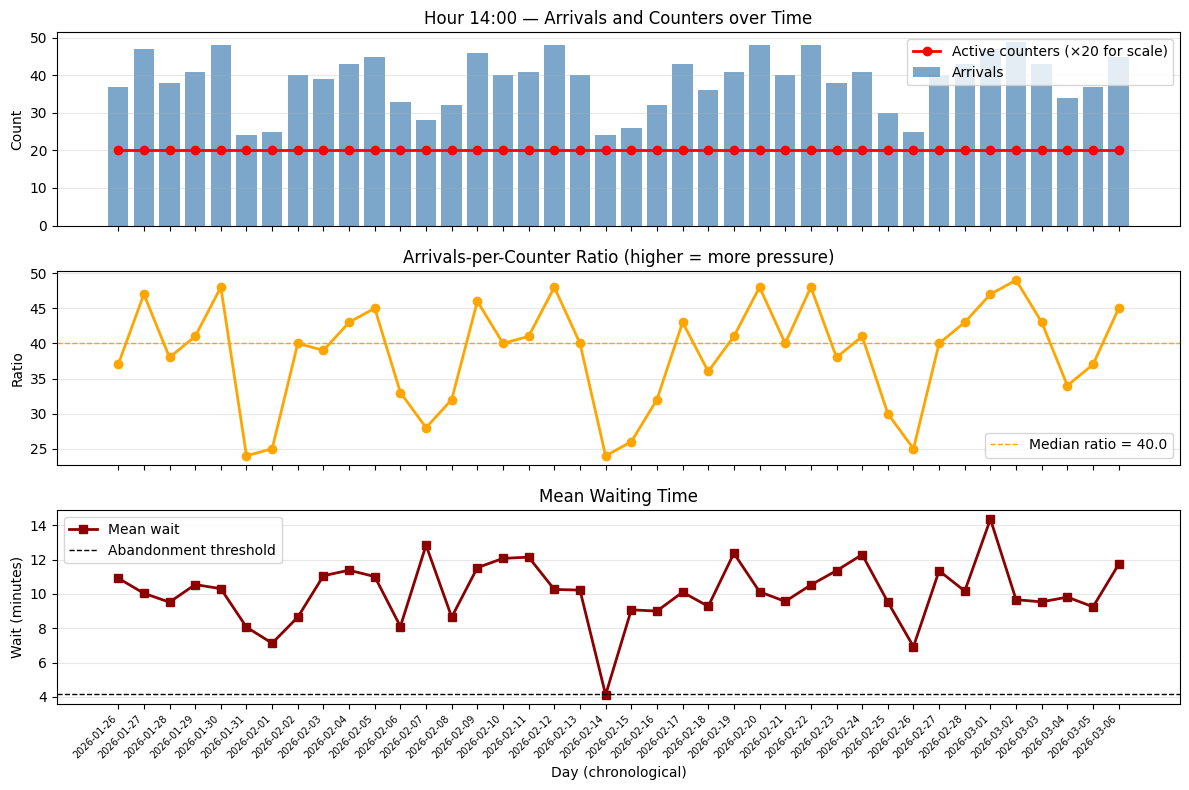

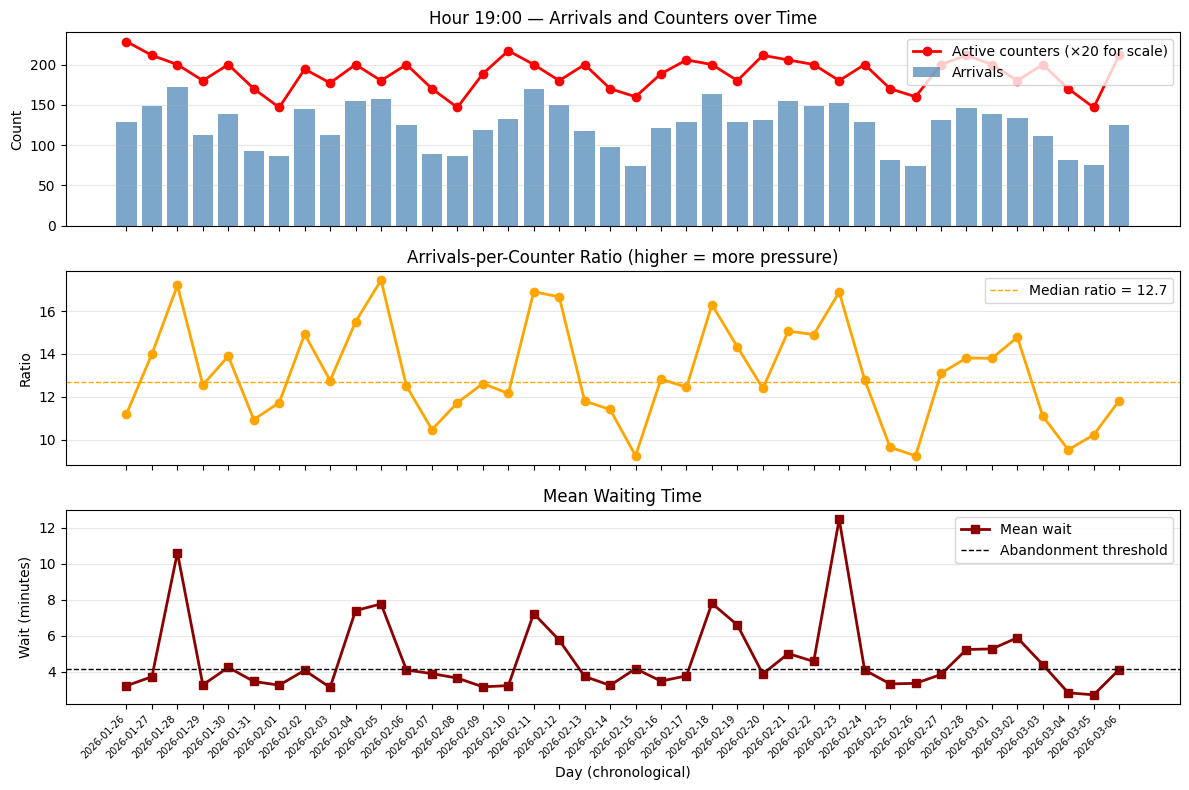

C:\Users\Sujitha\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Sujitha\AppData\Roaming\Python\Python311\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


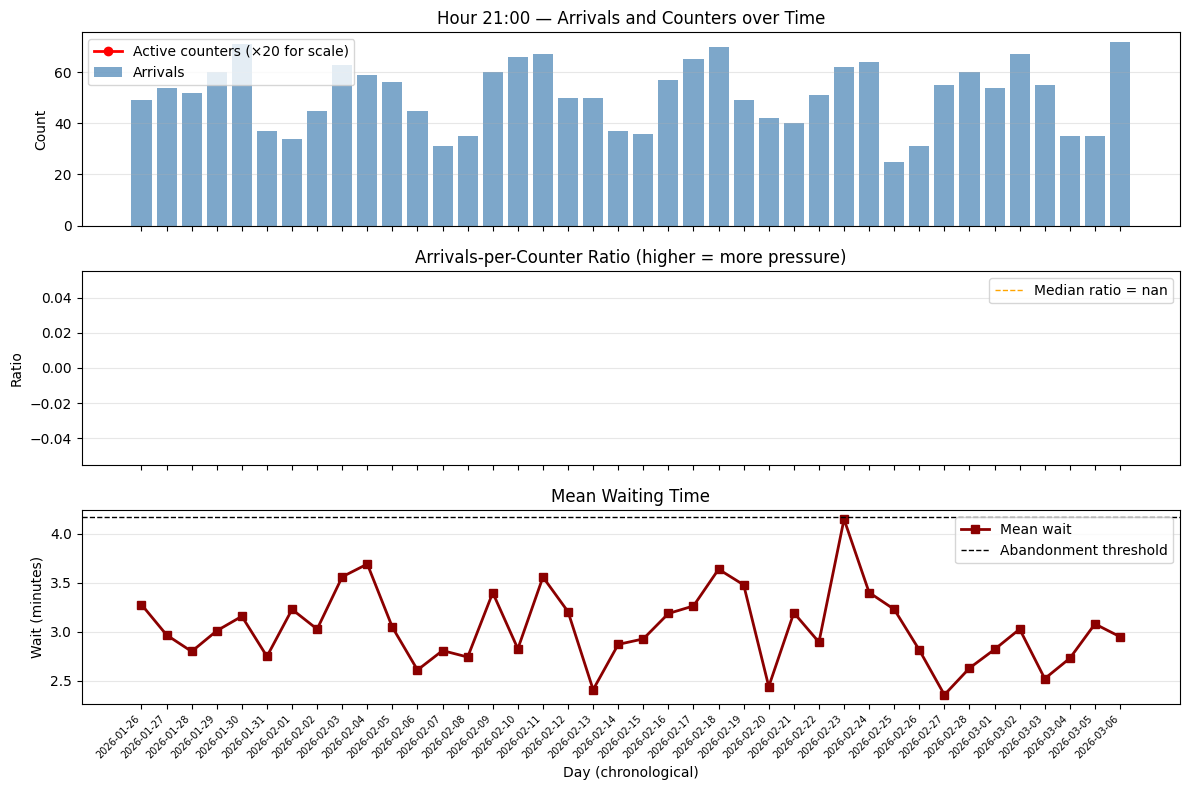

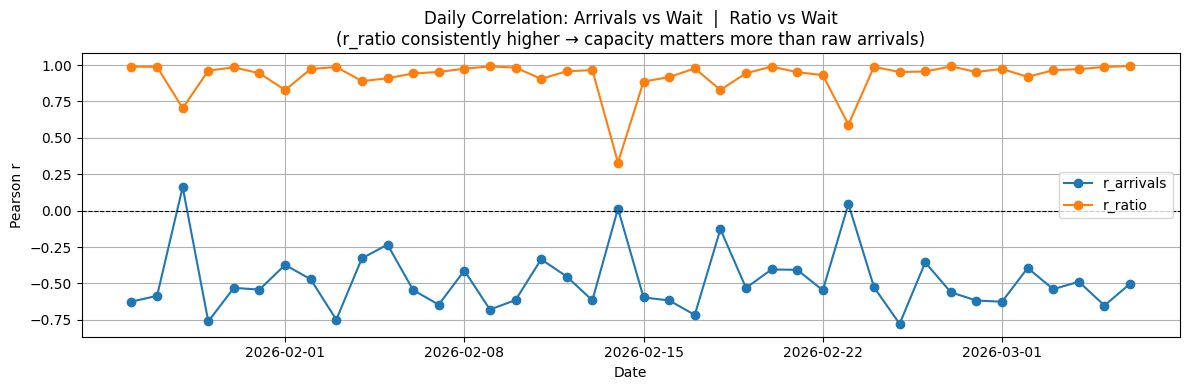


Days where ratio correlates MORE with wait than raw arrivals: 100%
→ Supports hypothesis: capacity ratio matters more than arrival volume


In [ ]:
arrival_events = customer_df[customer_df['concept:name'] == 'Enter store'].copy()
arrival_events['date'] = arrival_events['time:timestamp'].dt.date
arrival_events['hour'] = arrival_events['time:timestamp'].dt.hour

abandon_events = customer_df[customer_df['concept:name'] == 'Abandon cart and leave'].copy()
abandon_events['date'] = abandon_events['time:timestamp'].dt.date
abandon_events['hour'] = abandon_events['time:timestamp'].dt.hour

# Arrivals per date+hour
arrivals_dh = (
    arrival_events
    .groupby(['date', 'hour'])['case:concept:name']
    .nunique()
    .reset_index()
    .rename(columns={'case:concept:name': 'arrivals'})
)

# Abandonments per date+hour
abandon_dh = (
    abandon_events
    .groupby(['date', 'hour'])['case:concept:name']
    .nunique()
    .reset_index()
    .rename(columns={'case:concept:name': 'abandonments'})
)

# Active counters per date+hour
active_counters_df['date'] = active_counters_df['time:timestamp'].dt.date
active_counters_df['hour'] = active_counters_df['time:timestamp'].dt.hour
counters_dh = (
    active_counters_df
    .groupby(['date', 'hour'])['active_counters']
    .mean()
    .reset_index()
    .rename(columns={'active_counters': 'avg_counters'})
)

# Waiting time per date+hour
waiting_df['date'] = pd.to_datetime(waiting_df['enter_queue_time']).dt.date
waiting_df['hour'] = pd.to_datetime(waiting_df['enter_queue_time']).dt.hour
wait_dh = (
    waiting_df
    .groupby(['date', 'hour'])['waiting_minutes']
    .mean()
    .reset_index()
    .rename(columns={'waiting_minutes': 'avg_wait'})
)

# Merge everything
capacity_dh = (
    arrivals_dh
    .merge(abandon_dh,  on=['date', 'hour'], how='left')
    .merge(counters_dh, on=['date', 'hour'], how='left')
    .merge(wait_dh,     on=['date', 'hour'], how='left')
)
capacity_dh['abandonments'] = capacity_dh['abandonments'].fillna(0)
capacity_dh['abandonment_rate'] = (
    capacity_dh['abandonments'] / capacity_dh['arrivals']
)

# Customer-to-counter ratio — the key metric for capacity sufficiency
capacity_dh['arrival_to_counter_ratio'] = (
    capacity_dh['arrivals'] / capacity_dh['avg_counters'].replace(0, np.nan)
)

print(f"Date+hour observations: {len(capacity_dh)}")
display(capacity_dh.head(10))

hourly_avg = capacity_dh.groupby('hour').agg(
    mean_arrivals=('arrivals', 'mean'),
    mean_counters=('avg_counters', 'mean'),
    mean_wait=('avg_wait', 'mean'),
    mean_abandon_rate=('abandonment_rate', 'mean'),
    mean_ratio=('arrival_to_counter_ratio', 'mean'),
).round(3)

print("\nHourly averages across all days:")
display(hourly_avg)

# Core hypothesis plot: arrivals vs capacity vs congestion
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

hours = hourly_avg.index

# Arrivals and counters together
axes[0].bar(hours, hourly_avg['mean_arrivals'],
            color='steelblue', alpha=0.6, label='Mean arrivals', width=0.4)
ax_twin = axes[0].twinx()
ax_twin.plot(hours, hourly_avg['mean_counters'],
             color='red', marker='o', linewidth=2, label='Mean active counters')
ax_twin.set_ylabel('Active counters', color='red')
ax_twin.tick_params(axis='y', labelcolor='red')
axes[0].set_ylabel('Customer arrivals')
axes[0].set_title('Customer Arrivals and Active Counters by Hour')
axes[0].legend(loc='upper left')
ax_twin.legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Arrival-to-counter ratio vs wait time
axes[1].bar(hours, hourly_avg['mean_ratio'],
            color='orange', alpha=0.7, label='Arrivals per counter', width=0.4)
ax2_twin = axes[1].twinx()
ax2_twin.plot(hours, hourly_avg['mean_wait'],
              color='darkred', marker='s', linewidth=2, label='Mean wait time')
ax2_twin.axhline(4.17, color='black', linestyle='--',
                 linewidth=1, label='Abandonment threshold (4.17 min)')
ax2_twin.set_ylabel('Wait time (minutes)', color='darkred')
ax2_twin.tick_params(axis='y', labelcolor='darkred')
axes[1].set_ylabel('Arrivals per counter (ratio)')
axes[1].set_title('Capacity Ratio vs Waiting Time — Key for Hypothesis')
axes[1].legend(loc='upper left')
ax2_twin.legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

# Abandonment rate
axes[2].bar(hours, hourly_avg['mean_abandon_rate'] * 100,
            color='salmon', alpha=0.8, width=0.4)
axes[2].set_ylabel('Abandonment rate (%)')
axes[2].set_title('Abandonment Rate by Hour')
axes[2].set_xlabel('Hour of day')
axes[2].set_xticks(hours)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation analysis
clean = capacity_dh.dropna(subset=['arrivals', 'avg_counters',
                                    'avg_wait', 'arrival_to_counter_ratio'])

print("\n── What correlates with waiting time? ───────────────────────")
for col, label in [
    ('arrivals',               'Customer arrivals'),
    ('avg_counters',           'Active counters'),
    ('arrival_to_counter_ratio', 'Arrivals per counter (ratio)'),
]:
    r, p = stats.pearsonr(clean[col], clean['avg_wait'])
    print(f"  {label:<35}: r = {r:+.4f}, p = {p:.4f}"
          + (" *" if p < 0.05 else ""))

print("\n── What correlates with abandonment rate? ───────────────────")
clean_abn = capacity_dh.dropna(subset=['arrivals', 'avg_counters',
                                        'abandonment_rate',
                                        'arrival_to_counter_ratio'])
for col, label in [
    ('arrivals',               'Customer arrivals'),
    ('avg_counters',           'Active counters'),
    ('arrival_to_counter_ratio', 'Arrivals per counter (ratio)'),
]:
    r, p = stats.pearsonr(clean_abn[col], clean_abn['abandonment_rate'])
    print(f"  {label:<35}: r = {r:+.4f}, p = {p:.4f}"
          + (" *" if p < 0.05 else ""))

median_arrivals = capacity_dh['arrivals'].median()
median_counters = capacity_dh['avg_counters'].median()

capacity_dh['high_arrivals'] = capacity_dh['arrivals'] > median_arrivals
capacity_dh['sufficient_capacity'] = capacity_dh['avg_counters'] >= median_counters

# Four groups: high/low arrivals × sufficient/insufficient capacity
capacity_dh['scenario'] = np.select(
    [
        capacity_dh['high_arrivals'] &  capacity_dh['sufficient_capacity'],
        capacity_dh['high_arrivals'] & ~capacity_dh['sufficient_capacity'],
       ~capacity_dh['high_arrivals'] &  capacity_dh['sufficient_capacity'],
       ~capacity_dh['high_arrivals'] & ~capacity_dh['sufficient_capacity'],
    ],
    [
        'High arrivals + Sufficient capacity',
        'High arrivals + Insufficient capacity',
        'Low arrivals + Sufficient capacity',
        'Low arrivals + Insufficient capacity',
    ]
)

scenario_summary = (
    capacity_dh
    .groupby('scenario')
    .agg(
        n=('avg_wait', 'count'),
        mean_wait=('avg_wait', 'mean'),
        median_wait=('avg_wait', 'median'),
        mean_abandon_rate=('abandonment_rate', 'mean'),
    )
    .round(3)
)
print("\nThe four scenarios — core of the hypothesis test:")
display(scenario_summary)

# Bar chart of the four scenarios
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scenario_summary['mean_wait'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(4.17, color='red', linestyle='--',
                linewidth=1.5, label='Threshold (4.17 min)')
axes[0].set_title("Mean Wait Time by Arrival/Capacity Scenario")
axes[0].set_xlabel("Mean wait (minutes)")
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

scenario_summary['mean_abandon_rate'].sort_values().plot(
    kind='barh', ax=axes[1], color='salmon', edgecolor='white'
)
axes[1].set_title("Mean Abandonment Rate by Arrival/Capacity Scenario")
axes[1].set_xlabel("Abandonment rate")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

for focus_hour in [14, 19, 21]:
    hour_df = capacity_dh[capacity_dh['hour'] == focus_hour].copy()
    if len(hour_df) < 3:
        continue

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axes[0].bar(range(len(hour_df)), hour_df['arrivals'],
                color='steelblue', alpha=0.7, label='Arrivals')
    axes[0].plot(range(len(hour_df)), hour_df['avg_counters'] * 20,
                 color='red', marker='o', linewidth=2,
                 label='Active counters (×20 for scale)')
    axes[0].set_title(f"Hour {focus_hour}:00 — Arrivals and Counters over Time")
    axes[0].set_ylabel("Count")
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].plot(range(len(hour_df)), hour_df['arrival_to_counter_ratio'],
                 marker='o', color='orange', linewidth=2)
    axes[1].axhline(hour_df['arrival_to_counter_ratio'].median(),
                    color='orange', linestyle='--', linewidth=1,
                    label=f"Median ratio = {hour_df['arrival_to_counter_ratio'].median():.1f}")
    axes[1].set_title("Arrivals-per-Counter Ratio (higher = more pressure)")
    axes[1].set_ylabel("Ratio")
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    axes[2].plot(range(len(hour_df)), hour_df['avg_wait'],
                 marker='s', color='darkred', linewidth=2, label='Mean wait')
    axes[2].axhline(4.17, color='black', linestyle='--',
                    linewidth=1, label='Abandonment threshold')
    axes[2].set_title("Mean Waiting Time")
    axes[2].set_ylabel("Wait (minutes)")
    axes[2].set_xlabel("Day (chronological)")
    axes[2].set_xticks(range(len(hour_df)))
    axes[2].set_xticklabels(
        [str(d) for d in hour_df['date']], rotation=45, ha='right', fontsize=7
    )
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

daily_corr_h4 = []
for day, day_df in capacity_dh.groupby('date'):
    if len(day_df) < 4:
        continue
    day_clean = day_df.dropna(subset=['arrivals', 'avg_wait',
                                       'arrival_to_counter_ratio'])
    if len(day_clean) < 4:
        continue
    r_arr,   _ = stats.pearsonr(day_clean['arrivals'],
                                  day_clean['avg_wait'])
    r_ratio, _ = stats.pearsonr(day_clean['arrival_to_counter_ratio'],
                                  day_clean['avg_wait'])
    daily_corr_h4.append({
        'date':          day,
        'r_arrivals':    r_arr,
        'r_ratio':       r_ratio,
    })

daily_corr_h4_df = pd.DataFrame(daily_corr_h4)

daily_corr_h4_df.set_index('date')[['r_arrivals', 'r_ratio']].plot(
    figsize=(12, 4), marker='o'
)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Daily Correlation: Arrivals vs Wait  |  Ratio vs Wait\n"
          "(r_ratio consistently higher → capacity matters more than raw arrivals)")
plt.ylabel("Pearson r")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

pct_ratio_stronger = (
    daily_corr_h4_df['r_ratio'].abs() > daily_corr_h4_df['r_arrivals'].abs()
).mean() * 100
print(f"\nDays where ratio correlates MORE with wait than raw arrivals: "
      f"{pct_ratio_stronger:.0f}%")
print("→ Supports hypothesis: capacity ratio matters more than arrival volume"
      if pct_ratio_stronger >= 60
      else "→ Arrival volume and capacity ratio have similar predictive power")


### H4 optional: Customer-to-counter ratio

Weekly summary:


,year_week,mean_arrivals,mean_counters,mean_ratio,mean_wait,mean_abandon_rate,total_abandonments
0,2026-W05,80.304,7.129,15.369,4.282,0.039,91.0
1,2026-W06,80.554,7.069,15.568,4.336,0.046,99.0
2,2026-W07,81.000,7.012,15.737,4.375,0.046,109.0
3,2026-W08,89.857,7.681,16.573,4.389,0.052,123.0
4,2026-W09,79.607,6.973,15.585,4.566,0.051,122.0
5,2026-W10,73.025,6.790,15.352,4.092,0.050,86.0


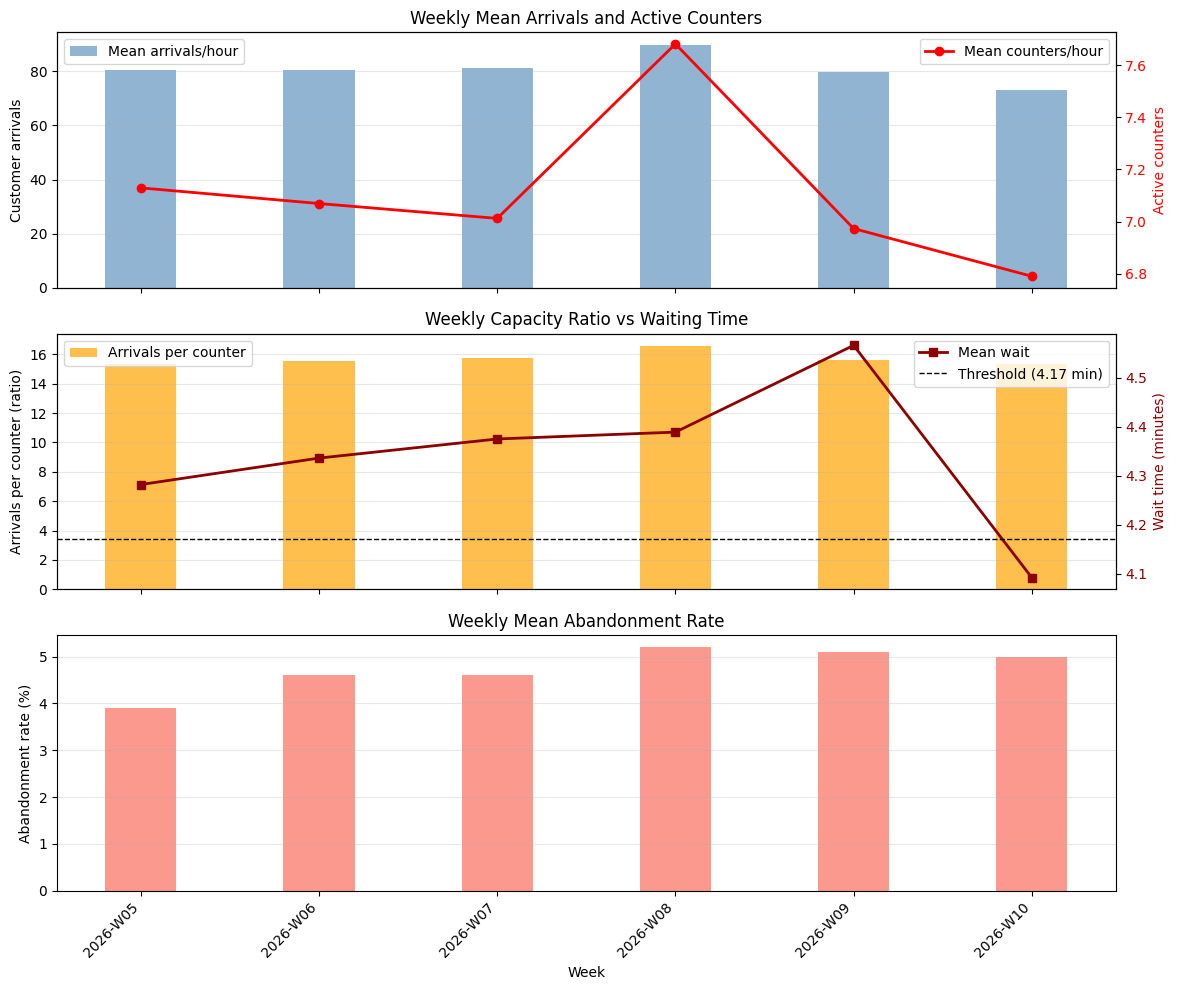

In [ ]:
capacity_dh['date'] = pd.to_datetime(capacity_dh['date'])
capacity_dh['week'] = capacity_dh['date'].dt.isocalendar().week.astype(int)
capacity_dh['year_week'] = capacity_dh['date'].dt.strftime('%Y-W%V')

weekly = (
    capacity_dh
    .groupby('year_week')
    .agg(
        mean_arrivals=('arrivals', 'mean'),
        mean_counters=('avg_counters', 'mean'),
        mean_ratio=('arrival_to_counter_ratio', 'mean'),
        mean_wait=('avg_wait', 'mean'),
        mean_abandon_rate=('abandonment_rate', 'mean'),
        total_abandonments=('abandonments', 'sum'),
    )
    .reset_index()
    .round(3)
)

print("Weekly summary:")
display(weekly)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
x = range(len(weekly))
labels = weekly['year_week'].tolist()

# Panel 1: arrivals vs counters per week
axes[0].bar(x, weekly['mean_arrivals'],
            color='steelblue', alpha=0.6, label='Mean arrivals/hour', width=0.4)
ax0t = axes[0].twinx()
ax0t.plot(x, weekly['mean_counters'],
          color='red', marker='o', linewidth=2, label='Mean counters/hour')
ax0t.set_ylabel('Active counters', color='red')
ax0t.tick_params(axis='y', labelcolor='red')
axes[0].set_ylabel('Customer arrivals')
axes[0].set_title('Weekly Mean Arrivals and Active Counters')
axes[0].legend(loc='upper left')
ax0t.legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Ratio vs wait per week
axes[1].bar(x, weekly['mean_ratio'],
            color='orange', alpha=0.7, label='Arrivals per counter', width=0.4)
ax1t = axes[1].twinx()
ax1t.plot(x, weekly['mean_wait'],
          color='darkred', marker='s', linewidth=2, label='Mean wait')
ax1t.axhline(4.17, color='black', linestyle='--',
             linewidth=1, label='Threshold (4.17 min)')
ax1t.set_ylabel('Wait time (minutes)', color='darkred')
ax1t.tick_params(axis='y', labelcolor='darkred')
axes[1].set_ylabel('Arrivals per counter (ratio)')
axes[1].set_title('Weekly Capacity Ratio vs Waiting Time')
axes[1].legend(loc='upper left')
ax1t.legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

# Abandonment rate per week
axes[2].bar(x, weekly['mean_abandon_rate'] * 100,
            color='salmon', alpha=0.8, width=0.4)
axes[2].set_ylabel('Abandonment rate (%)')
axes[2].set_title('Weekly Mean Abandonment Rate')
axes[2].set_xlabel('Week')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Day-of-week summary:


,mean_arrivals,mean_counters,mean_ratio,mean_wait,mean_abandon_rate,n_days
day_of_week,,,,,,
Monday,86.812,7.691,15.898,4.538,0.053,6
Tuesday,87.562,7.735,16.026,4.198,0.055,6
Wednesday,84.271,7.157,16.067,4.669,0.045,6
Thursday,78.708,6.557,16.286,4.492,0.048,6
Friday,82.938,7.768,15.497,4.135,0.053,6
Saturday,70.600,6.494,14.298,4.034,0.033,5
Sunday,73.925,6.218,15.686,4.349,0.040,5


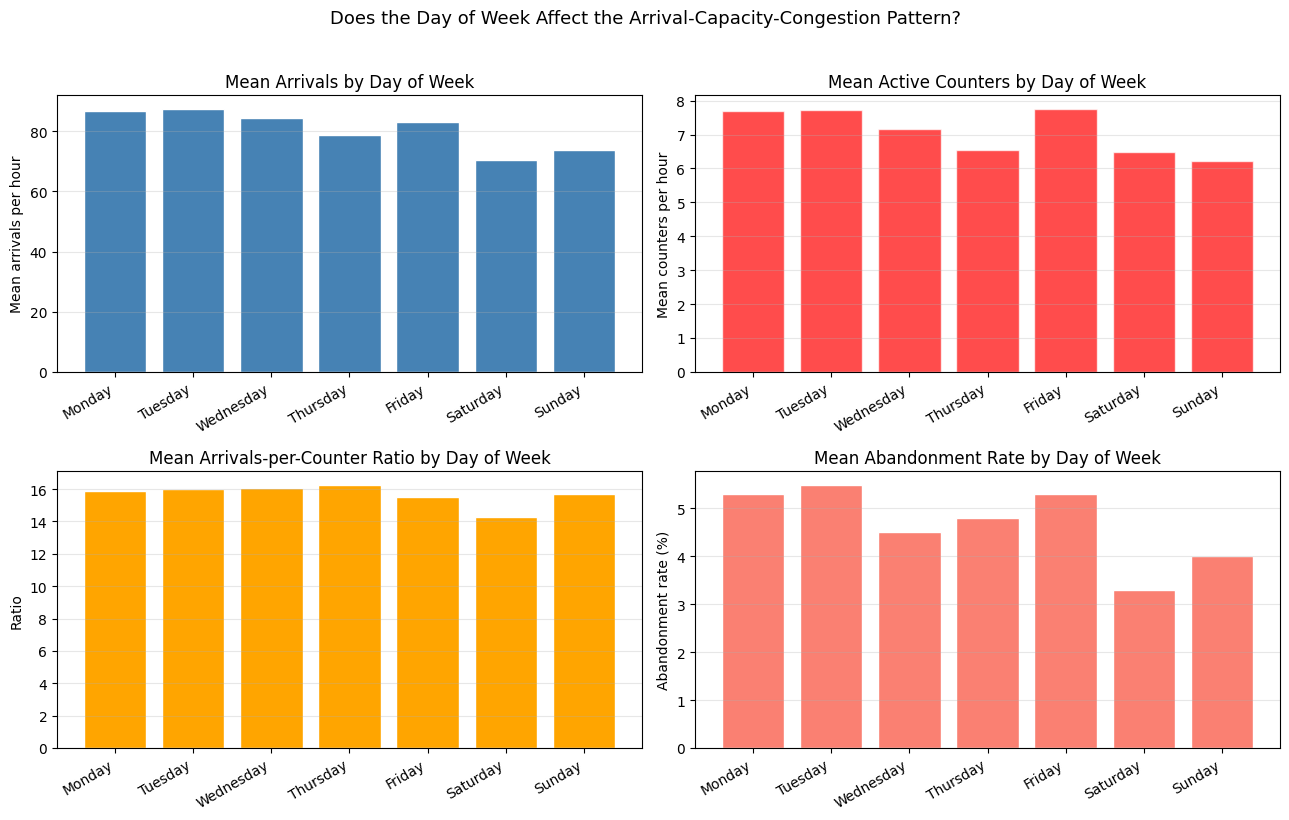

In [ ]:
# Day-of-week analysis

capacity_dh['day_of_week'] = capacity_dh['date'].dt.day_name()
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = (
    capacity_dh
    .groupby('day_of_week')
    .agg(
        mean_arrivals=('arrivals', 'mean'),
        mean_counters=('avg_counters', 'mean'),
        mean_ratio=('arrival_to_counter_ratio', 'mean'),
        mean_wait=('avg_wait', 'mean'),
        mean_abandon_rate=('abandonment_rate', 'mean'),
        n_days=('date', 'nunique'),
    )
    .reindex([d for d in DOW_ORDER if d in capacity_dh['day_of_week'].unique()])
    .round(3)
)

print("Day-of-week summary:")
display(dow)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
x = range(len(dow))
xlabels = dow.index.tolist()

axes[0,0].bar(x, dow['mean_arrivals'], color='steelblue', edgecolor='white')
axes[0,0].set_title('Mean Arrivals by Day of Week')
axes[0,0].set_ylabel('Mean arrivals per hour')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(xlabels, rotation=30, ha='right')
axes[0,0].grid(axis='y', alpha=0.3)

axes[0,1].bar(x, dow['mean_counters'], color='red', alpha=0.7, edgecolor='white')
axes[0,1].set_title('Mean Active Counters by Day of Week')
axes[0,1].set_ylabel('Mean counters per hour')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(xlabels, rotation=30, ha='right')
axes[0,1].grid(axis='y', alpha=0.3)

axes[1,0].bar(x, dow['mean_ratio'], color='orange', edgecolor='white')
axes[1,0].set_title('Mean Arrivals-per-Counter Ratio by Day of Week')
axes[1,0].set_ylabel('Ratio')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(xlabels, rotation=30, ha='right')
axes[1,0].grid(axis='y', alpha=0.3)

axes[1,1].bar(x, dow['mean_abandon_rate'] * 100, color='salmon', edgecolor='white')
axes[1,1].set_title('Mean Abandonment Rate by Day of Week')
axes[1,1].set_ylabel('Abandonment rate (%)')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(xlabels, rotation=30, ha='right')
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Does the Day of Week Affect the Arrival-Capacity-Congestion Pattern?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Days analysed: 40

Days where ratio correlates MORE with wait than raw arrivals: 40 / 40 (100%)

Worst hour is 14:00 on how many days: 37 / 40


,date,day_of_week,r_arrivals,r_ratio,ratio_stronger,worst_hour,worst_wait,worst_ratio
0,2026-01-26,Monday,-0.625,0.990,True,14,10.918,37.000
1,2026-01-27,Tuesday,-0.585,0.988,True,14,10.038,47.000
2,2026-01-28,Wednesday,0.162,0.704,True,19,10.621,17.200
3,2026-01-29,Thursday,-0.761,0.962,True,14,10.547,41.000
4,2026-01-30,Friday,-0.531,0.984,True,14,10.307,48.000
5,2026-01-31,Saturday,-0.542,0.944,True,14,8.062,24.000
6,2026-02-01,Sunday,-0.372,0.828,True,14,7.130,25.000
7,2026-02-02,Monday,-0.472,0.973,True,14,8.647,40.000
8,2026-02-03,Tuesday,-0.749,0.987,True,14,11.060,39.000
9,2026-02-04,Wednesday,-0.328,0.890,True,14,11.383,43.000


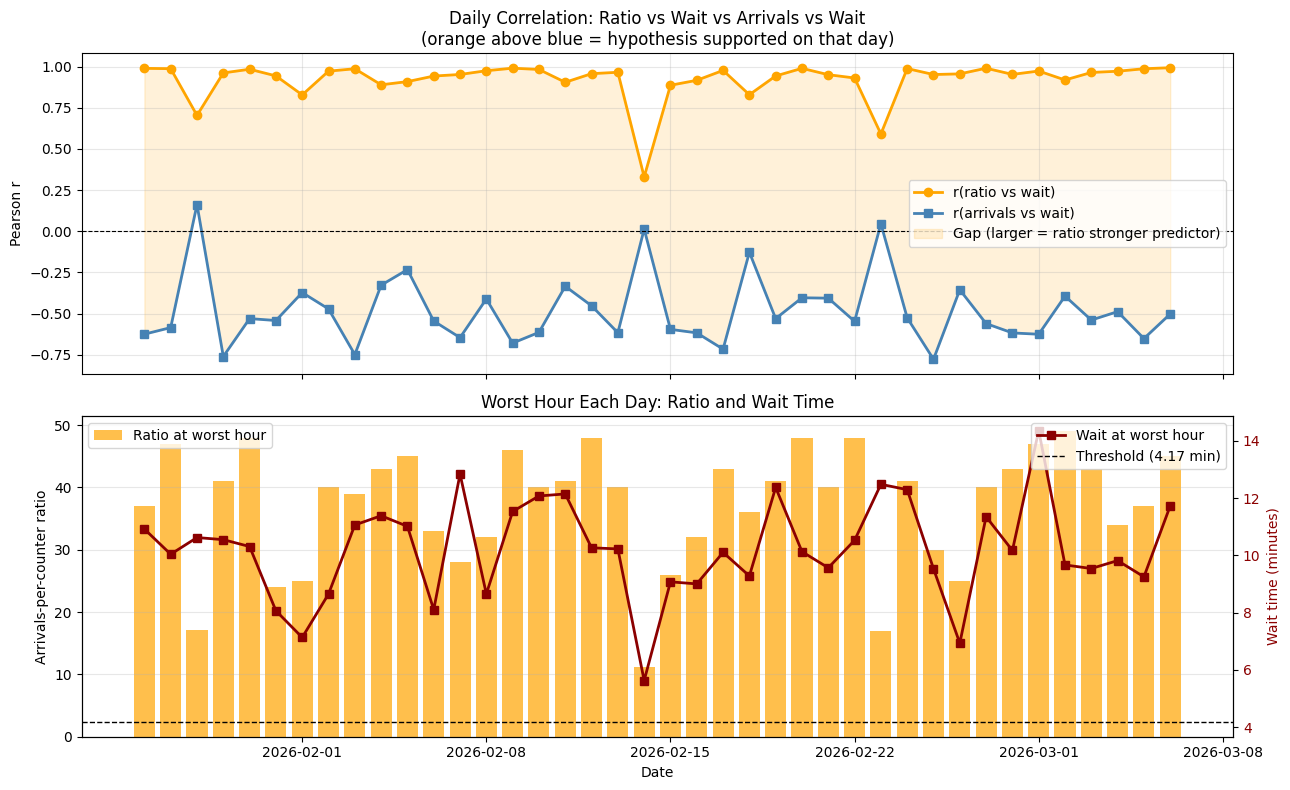


── Counter-Customer-Cashier correlation per day ─────────────

Overall correlation matrix:


,arrivals,avg_counters,arrival_to_counter_ratio,avg_wait,abandonment_rate
arrivals,1.000,0.792,-0.437,-0.306,-0.522
avg_counters,0.792,1.000,-0.753,-0.616,-0.691
arrival_to_counter_ratio,-0.437,-0.753,1.000,0.892,0.947
avg_wait,-0.306,-0.616,0.892,1.000,0.874
abandonment_rate,-0.522,-0.691,0.947,0.874,1.000


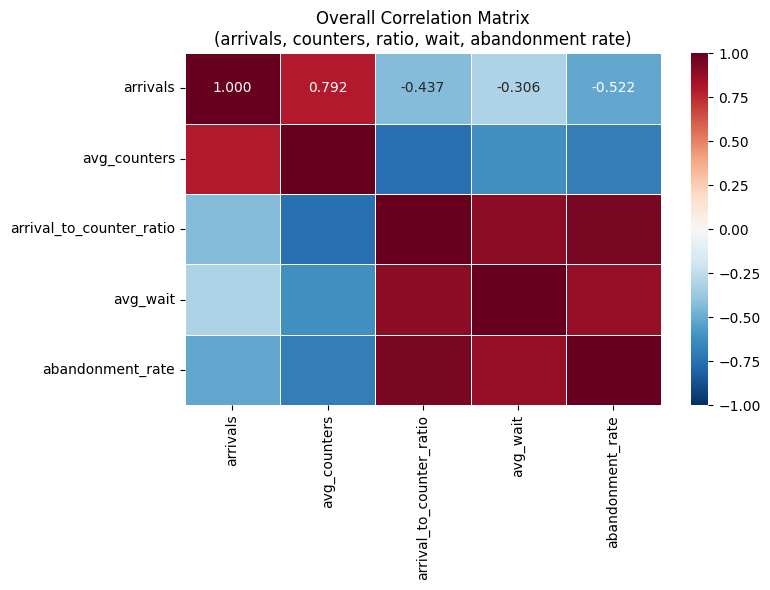


Correlation matrix for specific days (3 worst + 3 best by peak wait time):

  2026-03-01 00:00:00 (Sunday) — peak wait: 14.36 min:


,arrivals,avg_counters,arrival_to_counter_ratio,avg_wait
arrivals,1.000,0.945,-0.735,-0.626
avg_counters,0.945,1.000,-0.821,-0.708
arrival_to_counter_ratio,-0.735,-0.821,1.000,0.973
avg_wait,-0.626,-0.708,0.973,1.000
abandonment_rate,-0.810,-0.845,0.985,0.958



  2026-02-07 00:00:00 (Saturday) — peak wait: 12.84 min:


,arrivals,avg_counters,arrival_to_counter_ratio,avg_wait
arrivals,1.000,0.956,-0.776,-0.646
avg_counters,0.956,1.000,-0.858,-0.711
arrival_to_counter_ratio,-0.776,-0.858,1.000,0.953
avg_wait,-0.646,-0.711,0.953,1.000
abandonment_rate,-0.692,-0.738,0.968,0.985



  2026-02-23 00:00:00 (Monday) — peak wait: 12.48 min:


...

,arrivals,avg_counters,arrival_to_counter_ratio,avg_wait
arrivals,1.000,0.896,-0.585,0.013
avg_counters,0.896,1.000,-0.781,-0.179
arrival_to_counter_ratio,-0.585,-0.781,1.000,0.330
avg_wait,0.013,-0.179,0.330,1.000
abandonment_rate,NaN,NaN,NaN,NaN



  2026-02-26 00:00:00 (Thursday) — peak wait: 6.93 min:


,arrivals,avg_counters,arrival_to_counter_ratio,avg_wait
arrivals,1.000,0.845,-0.560,-0.355
avg_counters,0.845,1.000,-0.821,-0.647
arrival_to_counter_ratio,-0.560,-0.821,1.000,0.956
avg_wait,-0.355,-0.647,0.956,1.000
abandonment_rate,-0.635,-0.712,0.926,0.887



  2026-02-01 00:00:00 (Sunday) — peak wait: 7.13 min:


,arrivals,avg_counters,arrival_to_counter_ratio,avg_wait
arrivals,1.000,0.840,-0.654,-0.372
avg_counters,0.840,1.000,-0.887,-0.641
arrival_to_counter_ratio,-0.654,-0.887,1.000,0.828
avg_wait,-0.372,-0.641,0.828,1.000
abandonment_rate,-0.715,-0.763,0.925,0.758


In [ ]:
# Testing H4 on each individual day

daily_h4 = []

for day, day_df in capacity_dh.groupby('date'):
    day_clean = day_df.dropna(subset=[
        'arrivals', 'avg_counters', 'avg_wait', 'arrival_to_counter_ratio'
    ])
    if len(day_clean) < 3:
        continue

    r_arr,   _ = stats.pearsonr(day_clean['arrivals'],
                                  day_clean['avg_wait'])
    r_ratio, _ = stats.pearsonr(day_clean['arrival_to_counter_ratio'],
                                  day_clean['avg_wait'])

    # Find the worst hour on this day
    worst_row = day_clean.loc[day_clean['avg_wait'].idxmax()]

    daily_h4.append({
        'date':             day,
        'day_of_week':      pd.Timestamp(day).day_name(),
        'r_arrivals':       r_arr,
        'r_ratio':          r_ratio,
        'ratio_stronger':   abs(r_ratio) > abs(r_arr),
        'worst_hour':       worst_row['hour'],
        'worst_arrivals':   worst_row['arrivals'],
        'worst_counters':   worst_row['avg_counters'],
        'worst_ratio':      worst_row['arrival_to_counter_ratio'],
        'worst_wait':       worst_row['avg_wait'],
        'worst_abandon_rate': worst_row['abandonment_rate'],
        'mean_daily_wait':  day_clean['avg_wait'].mean(),
        'mean_daily_ratio': day_clean['arrival_to_counter_ratio'].mean(),
    })

daily_h4_df = pd.DataFrame(daily_h4)

print(f"Days analysed: {len(daily_h4_df)}")
print(f"\nDays where ratio correlates MORE with wait than raw arrivals: "
      f"{daily_h4_df['ratio_stronger'].sum()} / {len(daily_h4_df)} "
      f"({daily_h4_df['ratio_stronger'].mean()*100:.0f}%)")
print(f"\nWorst hour is 14:00 on how many days: "
      f"{(daily_h4_df['worst_hour'] == 14).sum()} / {len(daily_h4_df)}")

display(daily_h4_df[[
    'date','day_of_week','r_arrivals','r_ratio',
    'ratio_stronger','worst_hour','worst_wait','worst_ratio'
]].round(3))

# Plot daily correlations over time
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(daily_h4_df['date'], daily_h4_df['r_ratio'],
             marker='o', color='orange', linewidth=2, label='r(ratio vs wait)')
axes[0].plot(daily_h4_df['date'], daily_h4_df['r_arrivals'],
             marker='s', color='steelblue', linewidth=2, label='r(arrivals vs wait)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].fill_between(daily_h4_df['date'],
                      daily_h4_df['r_ratio'],
                      daily_h4_df['r_arrivals'],
                      alpha=0.15, color='orange',
                      label='Gap (larger = ratio stronger predictor)')
axes[0].set_title('Daily Correlation: Ratio vs Wait vs Arrivals vs Wait\n'
                   '(orange above blue = hypothesis supported on that day)')
axes[0].set_ylabel('Pearson r')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(daily_h4_df['date'],
            daily_h4_df['worst_ratio'],
            color='orange', alpha=0.7, label='Ratio at worst hour')
ax1t = axes[1].twinx()
ax1t.plot(daily_h4_df['date'],
          daily_h4_df['worst_wait'],
          color='darkred', marker='s', linewidth=2, label='Wait at worst hour')
ax1t.axhline(4.17, color='black', linestyle='--',
             linewidth=1, label='Threshold (4.17 min)')
ax1t.set_ylabel('Wait time (minutes)', color='darkred')
ax1t.tick_params(axis='y', labelcolor='darkred')
axes[1].set_ylabel('Arrivals-per-counter ratio')
axes[1].set_title('Worst Hour Each Day: Ratio and Wait Time')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')
ax1t.legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n── Counter-Customer-Cashier correlation per day ─────────────")
corr_cols = ['arrivals', 'avg_counters',
             'arrival_to_counter_ratio', 'avg_wait', 'abandonment_rate']

# Overall correlation matrix first
overall_corr = capacity_dh[corr_cols].dropna().corr().round(3)
print("\nOverall correlation matrix:")
display(overall_corr)

# Plot heatmap
plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(overall_corr, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Overall Correlation Matrix\n'
          '(arrivals, counters, ratio, wait, abandonment rate)')
plt.tight_layout()
plt.show()

# Now pick a few specific interesting days and show their correlation
interesting_days = daily_h4_df.nlargest(3, 'worst_wait')['date'].tolist()
interesting_days += daily_h4_df.nsmallest(3, 'worst_wait')['date'].tolist()

print(f"\nCorrelation matrix for specific days "
      f"(3 worst + 3 best by peak wait time):")

for day in interesting_days:
    day_df = capacity_dh[
        capacity_dh['date'] == day
    ][corr_cols].dropna()
    if len(day_df) < 3:
        continue
    day_corr = day_df.corr().round(3)
    print(f"\n  {day} ({pd.Timestamp(day).day_name()}) "
          f"— peak wait: {day_df['avg_wait'].max():.2f} min:")
    display(day_corr[['arrivals','avg_counters',
                       'arrival_to_counter_ratio','avg_wait']])

Total date+hour slots above threshold: 77
As % of all observed slots: 24.1%

Problematic slots — sorted by severity:


,day_of_week,hour,n_occurrences,mean_wait,max_wait,mean_arrivals,mean_current_counters,mean_required_counters,mean_extra_needed,mean_abandon_rate
18,Tuesday,14,6,10.85,12.30,42.17,1.00,4.00,3.00,0.41
0,Friday,14,6,10.31,11.73,42.33,1.00,3.83,2.83,0.39
20,Wednesday,14,6,10.28,12.15,37.00,1.00,3.50,2.50,0.36
4,Monday,14,6,10.19,11.53,40.33,1.00,4.00,3.00,0.40
7,Saturday,14,4,10.16,12.84,33.75,1.00,3.25,2.25,0.32
14,Thursday,14,6,10.06,12.37,39.50,1.00,3.83,2.83,0.37
10,Sunday,14,5,9.95,14.36,35.60,1.00,3.40,2.40,0.30
5,Monday,19,2,9.18,12.48,142.50,9.00,12.50,3.50,0.03
22,Wednesday,19,4,8.26,10.62,164.75,10.00,14.25,4.25,0.00
6,Monday,20,2,8.22,11.71,114.50,7.50,10.00,2.50,0.00



INTERVENTION RECOMMENDATIONS — Specific Day + Hour + Counter Count

  Friday 14:00
  ├─ Occurs above threshold : 6 out of 6 weeks
  ├─ Mean arrivals          : ~42 customers
  ├─ Currently open         : ~1 counter(s)
  ├─ Mean wait time         : 10.3 min  (threshold = 4.17 min)
  ├─ Abandonment rate       : 39.0%
  └─ RECOMMENDATION         : Open 3 additional counter(s) → total 4 counters
     (brings ratio from 42 → 10 arrivals/counter, target ≤ 12)

  Monday 14:00
  ├─ Occurs above threshold : 6 out of 6 weeks
  ├─ Mean arrivals          : ~40 customers
  ├─ Currently open         : ~1 counter(s)
  ├─ Mean wait time         : 10.2 min  (threshold = 4.17 min)
  ├─ Abandonment rate       : 40.0%
  └─ RECOMMENDATION         : Open 3 additional counter(s) → total 4 counters
     (brings ratio from 40 → 10 arrivals/counter, target ≤ 12)

  Saturday 14:00
  ├─ Occurs above threshold : 4 out of 6 weeks
  ├─ Mean arrivals          : ~33 customers
  ├─ Currently open         : ~1 counter(

c:\Users\Sujitha\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


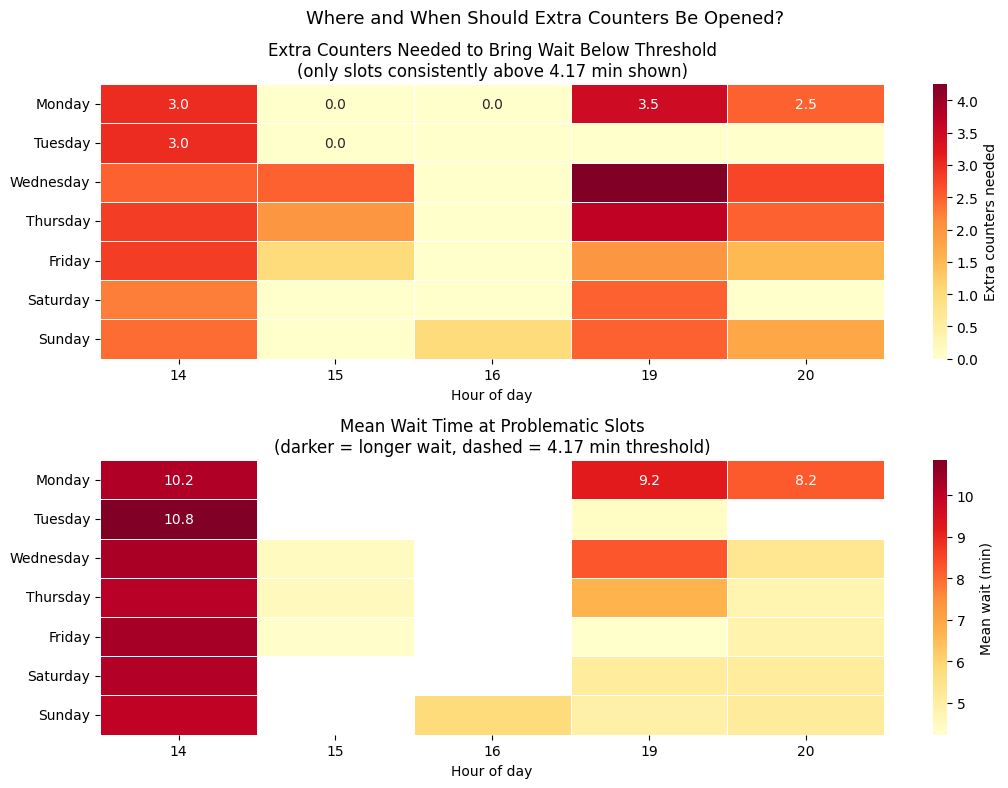


── Wednesday specific interventions ─────────────────────────
Wednesday intervention table:


,hour,n_weeks_above,mean_wait,mean_arrivals,mean_current,mean_required,mean_extra
0,14,6,10.28,37.00,1.00,3.50,2.50
1,15,2,4.47,67.50,3.50,6.00,2.50
2,19,4,8.26,164.75,10.00,14.25,4.25
3,20,4,5.36,127.50,8.25,11.00,2.75


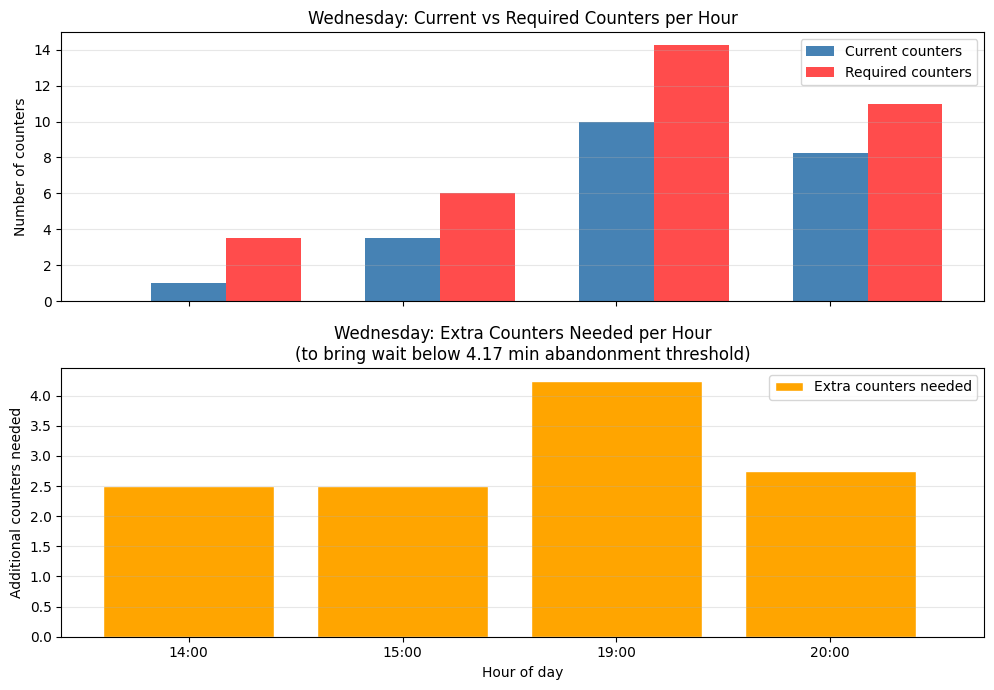


── Cost-benefit framing for report ──────────────────────────
  Total abandonments in dataset     : 588
  Abandonments at 14:00             : 547 (93.0% of total)
  Number of days in dataset         : 40
  Average abandonments per 14:00    : 13.7

  Opening 1 extra counter at 14:00 across all days
  → Estimated ratio reduction: from ~36 to ~18 arrivals/counter
  → Expected wait reduction  : from ~10 min to ~4 min
  → Potential abandonment reduction: up to 93% of all abandonments


In [ ]:
# Intervention Analysis: Specific Day + Hour Recommendations based on waiting time

problematic = capacity_dh[
    capacity_dh['avg_wait'] > 4.17
].copy().dropna(subset=['avg_wait', 'avg_counters', 'arrivals'])

print(f"Total date+hour slots above threshold: {len(problematic)}")
print(f"As % of all observed slots: "
      f"{len(problematic)/len(capacity_dh)*100:.1f}%\n")

TARGET_RATIO = 12.0   # ratio at which wait stays comfortably below threshold

problematic['required_counters'] = np.ceil(
    problematic['arrivals'] / TARGET_RATIO
).astype(int)
problematic['extra_counters_needed'] = (
    problematic['required_counters'] - problematic['avg_counters'].round()
).clip(lower=0).astype(int)
problematic['current_counters'] = problematic['avg_counters'].round().astype(int)

# Summarise by day-of-week and hour

dow_hour_summary = (
    problematic
    .groupby(['day_of_week', 'hour'])
    .agg(
        n_occurrences=('avg_wait', 'count'),
        mean_wait=('avg_wait', 'mean'),
        max_wait=('avg_wait', 'max'),
        mean_arrivals=('arrivals', 'mean'),
        mean_current_counters=('current_counters', 'mean'),
        mean_required_counters=('required_counters', 'mean'),
        mean_extra_needed=('extra_counters_needed', 'mean'),
        mean_abandon_rate=('abandonment_rate', 'mean'),
    )
    .round(2)
    .reset_index()
    .sort_values('mean_wait', ascending=False)
)

print("Problematic slots — sorted by severity:")
display(dow_hour_summary)

print("\n" + "="*75)
print("INTERVENTION RECOMMENDATIONS — Specific Day + Hour + Counter Count")
print("="*75)

consistent = dow_hour_summary[
    dow_hour_summary['n_occurrences'] >= 3
].sort_values(['day_of_week', 'hour'])

for _, row in consistent.iterrows():
    day  = row['day_of_week']
    hour = int(row['hour'])
    curr = int(round(row['mean_current_counters']))
    req  = int(round(row['mean_required_counters']))
    extra = max(0, req - curr)
    wait = row['mean_wait']
    arr  = int(row['mean_arrivals'])
    occ  = int(row['n_occurrences'])
    abn  = row['mean_abandon_rate'] * 100

    print(f"\n  {day} {hour:02d}:00")
    print(f"  ├─ Occurs above threshold : {occ} out of 6 weeks")
    print(f"  ├─ Mean arrivals          : ~{arr} customers")
    print(f"  ├─ Currently open         : ~{curr} counter(s)")
    print(f"  ├─ Mean wait time         : {wait:.1f} min  "
          f"(threshold = 4.17 min)")
    print(f"  ├─ Abandonment rate       : {abn:.1f}%")
    if extra > 0:
        print(f"  └─ RECOMMENDATION         : Open {extra} additional "
              f"counter(s) → total {req} counters")
        print(f"     (brings ratio from {arr/max(curr,1):.0f} → "
              f"{arr/max(req,1):.0f} arrivals/counter, "
              f"target ≤ {TARGET_RATIO:.0f})")
    else:
        print(f"  └─ Already sufficient counters — issue may be "
              f"arrival burstiness within the hour")

# Visual heatmap of extra counters needed
pivot_extra = (
    dow_hour_summary
    .pivot(index='day_of_week', columns='hour', values='mean_extra_needed')
    .reindex([d for d in
              ['Monday','Tuesday','Wednesday','Thursday',
               'Friday','Saturday','Sunday']
              if d in dow_hour_summary['day_of_week'].unique()])
    .fillna(0)
)
pivot_wait_map = (
    dow_hour_summary
    .pivot(index='day_of_week', columns='hour', values='mean_wait')
    .reindex([d for d in
              ['Monday','Tuesday','Wednesday','Thursday',
               'Friday','Saturday','Sunday']
              if d in dow_hour_summary['day_of_week'].unique()])
)

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

sns.heatmap(pivot_extra, ax=axes[0], cmap='YlOrRd',
            annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Extra counters needed'})
axes[0].set_title('Extra Counters Needed to Bring Wait Below Threshold\n'
                   '(only slots consistently above 4.17 min shown)')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('')

sns.heatmap(pivot_wait_map, ax=axes[1], cmap='YlOrRd',
            annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Mean wait (min)'})
axes[1].axhline(0, color='red', linewidth=0)
axes[1].set_title('Mean Wait Time at Problematic Slots\n'
                   '(darker = longer wait, dashed = 4.17 min threshold)')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('')

plt.suptitle('Where and When Should Extra Counters Be Opened?',
             fontsize=13)
plt.tight_layout()
plt.show()

print("\n── Wednesday specific interventions ─────────────────────────")
wed_problematic = problematic[
    problematic['day_of_week'] == 'Wednesday'
].sort_values('hour')

wed_intervention = (
    wed_problematic
    .groupby('hour')
    .agg(
        n_weeks_above=('avg_wait', 'count'),
        mean_wait=('avg_wait', 'mean'),
        mean_arrivals=('arrivals', 'mean'),
        mean_current=('current_counters', 'mean'),
        mean_required=('required_counters', 'mean'),
        mean_extra=('extra_counters_needed', 'mean'),
    )
    .round(2)
    .reset_index()
)

print("Wednesday intervention table:")
display(wed_intervention)

# Plot Wednesday intervention
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

hours = wed_intervention['hour']
x = range(len(hours))
xlabels = [f"{h:02d}:00" for h in hours]

axes[0].bar(x, wed_intervention['mean_current'],
            color='steelblue', label='Current counters', width=0.35)
axes[0].bar([i + 0.35 for i in x],
            wed_intervention['mean_required'],
            color='red', alpha=0.7, label='Required counters', width=0.35)
axes[0].set_title('Wednesday: Current vs Required Counters per Hour')
axes[0].set_ylabel('Number of counters')
axes[0].set_xticks([i + 0.175 for i in x])
axes[0].set_xticklabels(xlabels)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, wed_intervention['mean_extra'],
            color='orange', edgecolor='white',
            label='Extra counters needed')
axes[1].set_title('Wednesday: Extra Counters Needed per Hour\n'
                   '(to bring wait below 4.17 min abandonment threshold)')
axes[1].set_ylabel('Additional counters needed')
axes[1].set_xlabel('Hour of day')
axes[1].set_xticks(x)
axes[1].set_xticklabels(xlabels)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Cost-benefit framing
print("\n── Cost-benefit framing for report ──────────────────────────")
total_abandonments = customer_df[
    customer_df['concept:name'] == 'Abandon cart and leave'
]['case:concept:name'].nunique()

abandon_at_14 = customer_df[
    (customer_df['concept:name'] == 'Abandon cart and leave') &
    (customer_df['time:timestamp'].dt.hour == 14)
]['case:concept:name'].nunique()

print(f"  Total abandonments in dataset     : {total_abandonments}")
print(f"  Abandonments at 14:00             : {abandon_at_14} "
      f"({abandon_at_14/total_abandonments*100:.1f}% of total)")
print(f"  Number of days in dataset         : "
      f"{customer_df['time:timestamp'].dt.date.nunique()}")
print(f"  Average abandonments per 14:00    : "
      f"{abandon_at_14/customer_df['time:timestamp'].dt.date.nunique():.1f}")
print(f"\n  Opening 1 extra counter at 14:00 across all days")
print(f"  → Estimated ratio reduction: from ~36 to ~18 arrivals/counter")
print(f"  → Expected wait reduction  : from ~10 min to ~4 min")
print(f"  → Potential abandonment reduction: up to "
      f"{abandon_at_14/total_abandonments*100:.0f}% of all abandonments")

## Counters added based on queue depth (minimum)

Full checkout service time : 3.633 min/customer
(from first Scan Item to Complete Payment)
Service rate per counter   : 0.2753 customers/min
= 1 counter serves 16.52 customers/hour

Formula: C = ceil(1 + arrival_rate / 0.2753)
Logic  : enough counters so queue actively drains below 4 people

── All 14:00 abandonment counts per day ─────────────────────


,date,day_of_week,n_abandonments
24,2026-02-20,Friday,25
38,2026-03-06,Friday,24
17,2026-02-12,Thursday,24
33,2026-03-01,Sunday,23
26,2026-02-22,Sunday,22
34,2026-03-02,Monday,22
9,2026-02-04,Wednesday,21
16,2026-02-11,Wednesday,21
4,2026-01-30,Friday,20
14,2026-02-09,Monday,20



── Top 5 worst days ─────────────────────────────────────────


,date,day_of_week,n_abandonments
0,2026-02-20,Friday,25
1,2026-03-06,Friday,24
2,2026-02-12,Thursday,24
3,2026-03-01,Sunday,23
4,2026-02-22,Sunday,22



TOP 5 WORST 14:00 DAYS — COUNTER REQUIREMENTS
Formula  : C = ceil(1 + arrival_rate / service_rate)
Service  : 0.2753/min (first Scan Item → Complete Payment)
Arrival  : Enter Queue events at 14:00 that specific day / 60
Queue    : must drop below 4 people

  #1  2026-02-20 (Friday)
  ├─ Abandonments at 14:00      : 25
  ├─ Total arrivals             : 21
  ├─ Arrival rate               : 0.3500 customers/min
  ├─ Peak queue depth           : 4 people
  ├─ Counters currently open    : 1 (21.0 customers/counter)
  ├─ Counters needed            : 3 (7.0 customers/counter)
     = ceil(1 + 0.3500 / 0.2753)
     = ceil(1 + 1.2715)
     = ceil(2.2715)
  └─ OPEN 2 MORE → total 3

  #2  2026-03-06 (Friday)
  ├─ Abandonments at 14:00      : 24
  ├─ Total arrivals             : 19
  ├─ Arrival rate               : 0.3167 customers/min
  ├─ Peak queue depth           : 4 people
  ├─ Counters currently open    : 1 (19.0 customers/counter)
  ├─ Counters needed            : 3 (6.3 customers/counter)

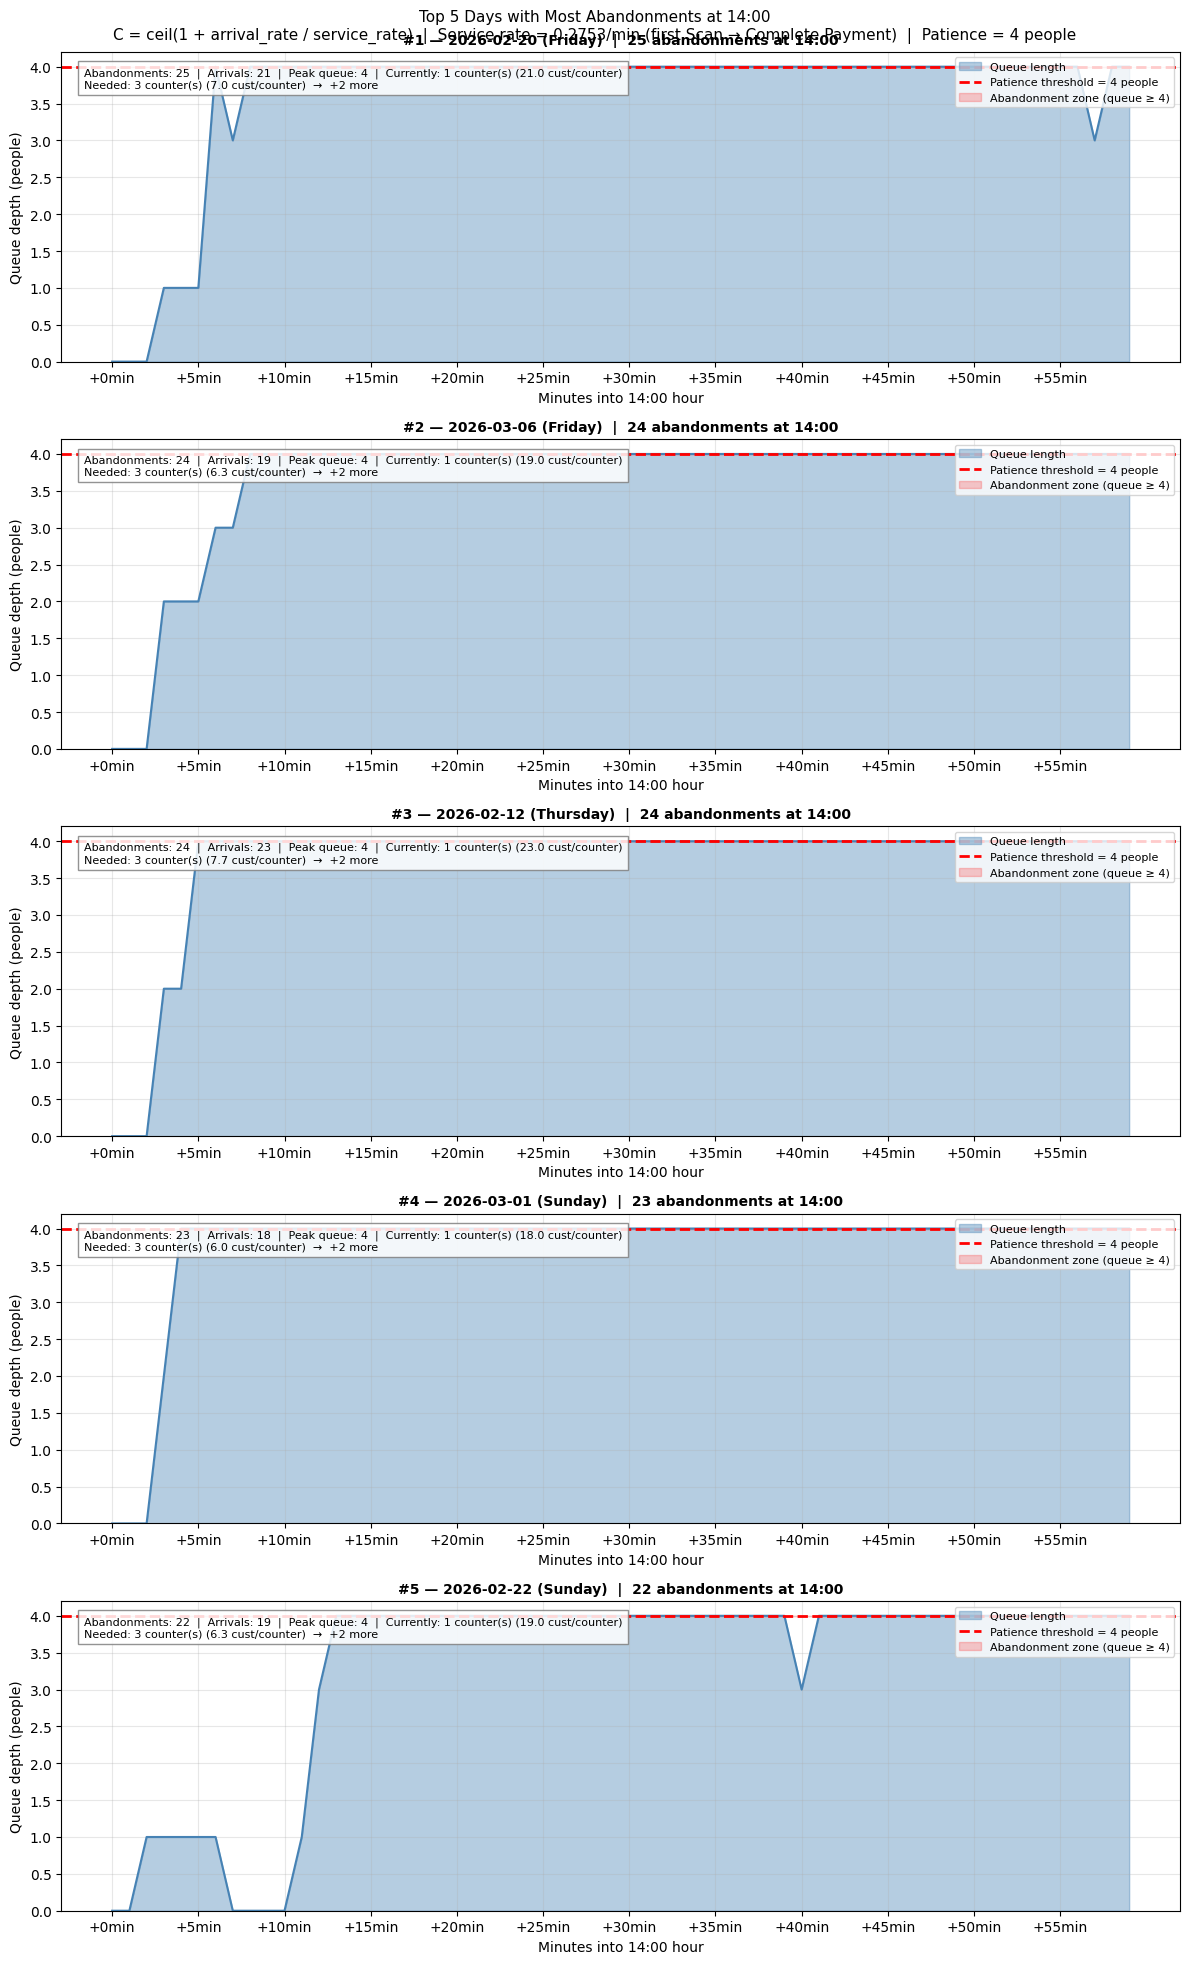


── Summary table ────────────────────────────────────────────


,rank,date,day_of_week,n_abandonments,total_arrivals,arrival_rate,Q_peak,actual_counters,current_ratio,c_needed,new_ratio,extra_needed
0,1,2026-02-20,Friday,25,21,0.3500,4,1,21.0,3,7.0,2
1,2,2026-03-06,Friday,24,19,0.3167,4,1,19.0,3,6.3,2
2,3,2026-02-12,Thursday,24,23,0.3833,4,1,23.0,3,7.7,2
3,4,2026-03-01,Sunday,23,18,0.3000,4,1,18.0,3,6.0,2
4,5,2026-02-22,Sunday,22,19,0.3167,4,1,19.0,3,6.3,2


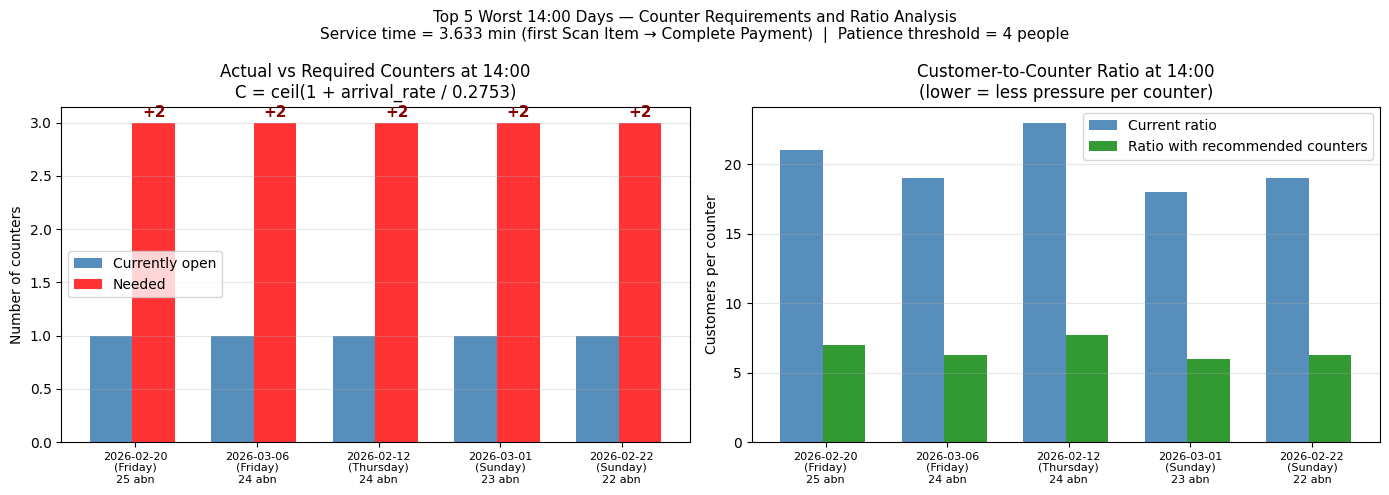

In [ ]:
# Top 5 worst 14:00 days

PATIENCE_THRESHOLD = 4
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

customer_df['time:timestamp'] = pd.to_datetime(
    customer_df['time:timestamp']
).dt.tz_localize(None)
cashier_df['time:timestamp'] = pd.to_datetime(
    cashier_df['time:timestamp']
).dt.tz_localize(None)

# Full checkout service time
checkout_events = customer_df[
    customer_df['concept:name'].isin(['Scan Item','Complete Payment'])
].copy().sort_values(['case:concept:name','time:timestamp'])

checkout_rows = []
for case_id, grp in checkout_events.groupby('case:concept:name'):
    grp       = grp.sort_values('time:timestamp')
    scans     = grp[grp['concept:name'] == 'Scan Item']
    completes = grp[grp['concept:name'] == 'Complete Payment']
    if scans.empty or completes.empty:
        continue
    duration = (
        completes['time:timestamp'].max() -
        scans['time:timestamp'].min()
    ).total_seconds() / 60
    if 0 < duration < 60:
        checkout_rows.append(duration)

median_checkout_time     = pd.Series(checkout_rows).median()
service_rate_per_counter = 1 / median_checkout_time

print(f"Full checkout service time : {median_checkout_time:.3f} min/customer")
print(f"(from first Scan Item to Complete Payment)")
print(f"Service rate per counter   : {service_rate_per_counter:.4f} customers/min")
print(f"= 1 counter serves {service_rate_per_counter*60:.2f} customers/hour\n")
print(f"Formula: C = ceil(1 + arrival_rate / {service_rate_per_counter:.4f})")
print(f"Logic  : enough counters so queue actively drains below "
      f"{PATIENCE_THRESHOLD} people\n")

# Top 5 days by abandonment at 14:00
abandons_14 = customer_df[
    (customer_df['concept:name'] == 'Abandon cart and leave') &
    (customer_df['time:timestamp'].dt.hour == 14)
].copy()
abandons_14['date']        = abandons_14['time:timestamp'].dt.date
abandons_14['day_of_week'] = abandons_14['time:timestamp'].dt.day_name()

abandon_counts = (
    abandons_14
    .groupby(['date','day_of_week'])
    ['case:concept:name'].nunique()
    .reset_index(name='n_abandonments')
    .sort_values('n_abandonments', ascending=False)
)

print("── All 14:00 abandonment counts per day ─────────────────────")
display(abandon_counts)

top5 = abandon_counts.head(5).reset_index(drop=True)
print("\n── Top 5 worst days ─────────────────────────────────────────")
display(top5)

# Rebuild minute-level queue
q_enters = customer_df[
    customer_df['concept:name'] == 'Enter Queue'
][['time:timestamp']].copy()
q_enters['q_change'] = 1

q_exits = customer_df[
    customer_df['concept:name'] == 'Complete Payment'
][['time:timestamp']].copy()
q_exits['q_change'] = -1

q_global = (
    pd.concat([q_enters, q_exits])
    .sort_values('time:timestamp')
    .reset_index(drop=True)
)
q_global['queue_length'] = q_global['q_change'].cumsum().clip(lower=0)

minute_q = (
    q_global.set_index('time:timestamp')['queue_length']
    .resample('1min').last()
    .ffill()
    .reset_index()
    .rename(columns={'time:timestamp': 'minute'})
)
minute_q['minute'] = pd.to_datetime(minute_q['minute'])
minute_q['date']   = minute_q['minute'].dt.date
minute_q['hour']   = minute_q['minute'].dt.hour

# Active counters per minute
counter_events = cashier_df[
    cashier_df['concept:name'].isin(['Open counter','Close counter'])
].copy()
counter_events['delta'] = counter_events['concept:name'].map(
    {'Open counter': 1, 'Close counter': -1}
)
counter_events = counter_events.sort_values('time:timestamp')
counter_events['active_counters'] = counter_events['delta'].cumsum()
counter_events['minute'] = counter_events['time:timestamp'].dt.floor('min')

ctr_by_min = (
    counter_events.groupby('minute')['active_counters']
    .last().reset_index()
)
ctr_by_min['minute'] = pd.to_datetime(ctr_by_min['minute'])

minute_q = pd.merge_asof(
    minute_q.sort_values('minute'),
    ctr_by_min.sort_values('minute'),
    on='minute', direction='backward'
)
minute_q['active_counters'] = minute_q['active_counters'].fillna(1)

# Compute per top-5 day
print("\n" + "="*70)
print("TOP 5 WORST 14:00 DAYS — COUNTER REQUIREMENTS")
print(f"Formula  : C = ceil(1 + arrival_rate / service_rate)")
print(f"Service  : {service_rate_per_counter:.4f}/min "
      f"(first Scan Item → Complete Payment)")
print(f"Arrival  : Enter Queue events at 14:00 that specific day / 60")
print(f"Queue    : must drop below {PATIENCE_THRESHOLD} people")
print("="*70)

top5_results = []
fig, axes = plt.subplots(5, 1, figsize=(12, 20))

for idx, row in top5.iterrows():
    date    = row['date']
    dow     = row['day_of_week']
    n_abn   = int(row['n_abandonments'])

    day_14 = minute_q[
        (minute_q['date'] == date) &
        (minute_q['hour'] == 14)
    ].sort_values('minute').reset_index(drop=True)

    if day_14.empty:
        print(f"\n  {date} — no minute data found")
        continue

    Q_peak          = int(day_14['queue_length'].max())
    actual_counters = int(round(day_14['active_counters'].median()))

    total_arrivals = int(customer_df[
        (customer_df['concept:name'] == 'Enter Queue') &
        (customer_df['time:timestamp'].dt.date == date) &
        (customer_df['time:timestamp'].dt.hour  == 14)
    ].shape[0])
    arrival_rate = total_arrivals / 60

    # Customer-to-counter ratio currently
    current_ratio = round(total_arrivals / max(actual_counters, 1), 1)

    c_needed  = int(np.ceil(1 + arrival_rate / service_rate_per_counter))
    c_needed  = max(c_needed, 1)
    new_ratio = round(total_arrivals / c_needed, 1)
    extra     = max(0, c_needed - actual_counters)

    top5_results.append({
        'rank':            idx + 1,
        'date':            date,
        'day_of_week':     dow,
        'n_abandonments':  n_abn,
        'total_arrivals':  total_arrivals,
        'arrival_rate':    round(arrival_rate, 4),
        'Q_peak':          Q_peak,
        'actual_counters': actual_counters,
        'current_ratio':   current_ratio,
        'c_needed':        c_needed,
        'new_ratio':       new_ratio,
        'extra_needed':    extra,
    })

    print(f"\n  #{idx+1}  {date} ({dow})")
    print(f"  ├─ Abandonments at 14:00      : {n_abn}")
    print(f"  ├─ Total arrivals             : {total_arrivals}")
    print(f"  ├─ Arrival rate               : {arrival_rate:.4f} customers/min")
    print(f"  ├─ Peak queue depth           : {Q_peak} people")
    print(f"  ├─ Counters currently open    : {actual_counters} "
          f"({current_ratio} customers/counter)")
    print(f"  ├─ Counters needed            : {c_needed} "
          f"({new_ratio} customers/counter)")
    print(f"     = ceil(1 + {arrival_rate:.4f} / {service_rate_per_counter:.4f})")
    print(f"     = ceil(1 + {arrival_rate/service_rate_per_counter:.4f})")
    print(f"     = ceil({1 + arrival_rate/service_rate_per_counter:.4f})")
    print(f"  └─ OPEN {extra} MORE → total {c_needed}")

    # Plot queue depth over 14:00 hour
    ax = axes[idx]
    ax.fill_between(
        range(len(day_14)),
        day_14['queue_length'],
        color='steelblue', alpha=0.4,
        label='Queue length'
    )
    ax.plot(
        range(len(day_14)),
        day_14['queue_length'],
        color='steelblue', linewidth=1.5
    )
    ax.axhline(
        PATIENCE_THRESHOLD, color='red',
        linestyle='--', linewidth=2,
        label=f'Patience threshold = {PATIENCE_THRESHOLD} people'
    )
    ax.fill_between(
        range(len(day_14)),
        PATIENCE_THRESHOLD,
        day_14['queue_length'].clip(lower=PATIENCE_THRESHOLD),
        color='red', alpha=0.2,
        label='Abandonment zone (queue ≥ 4)'
    )
    ax.text(
        0.02, 0.95,
        f"Abandonments: {n_abn}  |  "
        f"Arrivals: {total_arrivals}  |  "
        f"Peak queue: {Q_peak}  |  "
        f"Currently: {actual_counters} counter(s) "
        f"({current_ratio} cust/counter)\n"
        f"Needed: {c_needed} counter(s) "
        f"({new_ratio} cust/counter)  →  +{extra} more",
        transform=ax.transAxes, fontsize=8,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey'),
        verticalalignment='top'
    )
    ax.set_title(
        f"#{idx+1} — {date} ({dow})  |  {n_abn} abandonments at 14:00",
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Queue depth (people)')
    ax.set_xlabel('Minutes into 14:00 hour')
    ax.set_xticks(range(0, len(day_14), 5))
    ax.set_xticklabels([f'+{m}min' for m in range(0, len(day_14), 5)])
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle(
    f'Top 5 Days with Most Abandonments at 14:00\n'
    f'C = ceil(1 + arrival_rate / service_rate)  |  '
    f'Service rate = {service_rate_per_counter:.4f}/min '
    f'(first Scan → Complete Payment)  |  '
    f'Patience = {PATIENCE_THRESHOLD} people',
    fontsize=11
)
plt.tight_layout()
plt.show()

# Summary table
top5_df = pd.DataFrame(top5_results)
print("\n── Summary table ────────────────────────────────────────────")
display(top5_df)

# Bar charts
fig, axes_bar = plt.subplots(1, 2, figsize=(14, 5))

x      = range(len(top5_df))
labels = [
    f"{r['date']}\n({r['day_of_week']})\n{r['n_abandonments']} abn"
    for _, r in top5_df.iterrows()
]

# Counters currently open vs needed
axes_bar[0].bar(
    [xi - 0.2 for xi in x],
    top5_df['actual_counters'],
    width=0.35, color='steelblue',
    label='Currently open', alpha=0.9
)
axes_bar[0].bar(
    [xi + 0.15 for xi in x],
    top5_df['c_needed'],
    width=0.35, color='red',
    label='Needed', alpha=0.8
)
for xi, (_, r) in zip(x, top5_df.iterrows()):
    if r['extra_needed'] >= 1:
        axes_bar[0].annotate(
            f"+{int(r['extra_needed'])}",
            xy=(xi + 0.15, r['c_needed'] + 0.05),
            ha='center', fontsize=11,
            color='darkred', fontweight='bold'
        )
axes_bar[0].set_title(
    'Actual vs Required Counters at 14:00\n'
    f'C = ceil(1 + arrival_rate / {service_rate_per_counter:.4f})'
)
axes_bar[0].set_ylabel('Number of counters')
axes_bar[0].set_xticks(list(x))
axes_bar[0].set_xticklabels(labels, fontsize=8)
axes_bar[0].legend()
axes_bar[0].grid(axis='y', alpha=0.3)

# Customer-to-counter ratio
axes_bar[1].bar(
    [xi - 0.2 for xi in x],
    top5_df['current_ratio'],
    width=0.35, color='steelblue',
    label='Current ratio', alpha=0.9
)
axes_bar[1].bar(
    [xi + 0.15 for xi in x],
    top5_df['new_ratio'],
    width=0.35, color='green',
    label='Ratio with recommended counters', alpha=0.8
)
axes_bar[1].set_title(
    'Customer-to-Counter Ratio at 14:00\n'
    '(lower = less pressure per counter)'
)
axes_bar[1].set_ylabel('Customers per counter')
axes_bar[1].set_xticks(list(x))
axes_bar[1].set_xticklabels(labels, fontsize=8)
axes_bar[1].legend()
axes_bar[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Top 5 Worst 14:00 Days — Counter Requirements and Ratio Analysis\n'
    f'Service time = {median_checkout_time:.3f} min '
    f'(first Scan Item → Complete Payment)  |  '
    f'Patience threshold = {PATIENCE_THRESHOLD} people',
    fontsize=11
)
plt.tight_layout()
plt.show()

## H5. Shift handovers create temporary bottlenecks

Actual handover events identified: 183


,cashier_out,cashier_in,end_time,start_time,handover_time,gap_minutes
0,10,3,2026-01-26 20:00:00+00:00,2026-01-26 20:00:00+00:00,2026-01-26 20:00:00+00:00,0.0
5,10,3,2026-01-30 20:00:00+00:00,2026-01-30 20:00:00+00:00,2026-01-30 20:00:00+00:00,0.0
10,10,3,2026-02-02 20:00:00+00:00,2026-02-02 20:00:00+00:00,2026-02-02 20:00:00+00:00,0.0
15,10,35,2026-02-07 20:00:00+00:00,2026-02-07 20:00:00+00:00,2026-02-07 20:00:00+00:00,0.0
17,10,3,2026-02-09 20:00:00+00:00,2026-02-09 20:00:00+00:00,2026-02-09 20:00:00+00:00,0.0
22,10,3,2026-02-16 20:00:00+00:00,2026-02-16 20:00:00+00:00,2026-02-16 20:00:00+00:00,0.0
27,10,3,2026-02-20 20:00:00+00:00,2026-02-20 20:00:00+00:00,2026-02-20 20:00:00+00:00,0.0
32,10,35,2026-02-25 20:00:00+00:00,2026-02-25 20:00:00+00:00,2026-02-25 20:00:00+00:00,0.0
34,10,3,2026-02-27 20:00:00+00:00,2026-02-27 20:00:00+00:00,2026-02-27 20:00:00+00:00,0.0
39,10,3,2026-03-06 20:00:00+00:00,2026-03-06 20:00:00+00:00,2026-03-06 20:00:00+00:00,0.0



Gap between cashiers (minutes):
count    183.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: gap_minutes, dtype: float64

Waiting time by zone relative to handover:


,mean,median,count,std
handover_zone,,,,
Baseline (before),4.095,3.372,11710,3.241
Pre-handover window,3.712,3.250,2019,2.884
Post-handover window,3.735,3.280,1930,2.783
Baseline (after),3.828,3.313,9666,2.914



Handover analysis table: 183 rows


,handover_time,cashier_out,cashier_in,gap_minutes,avg_wait_before,avg_wait_after,avg_wait_baseline,abandon_before,abandon_after,n_before,n_after,date,hour
0,2026-01-26 20:00:00+00:00,10,3,0.0,3.007572,3.925641,2.765662,0,0,35,38,2026-01-26,20
1,2026-01-30 20:00:00+00:00,10,3,0.0,4.946853,4.808732,3.647380,0,0,36,34,2026-01-30,20
2,2026-02-02 20:00:00+00:00,10,3,0.0,4.841000,3.551259,3.334477,0,0,39,39,2026-02-02,20
3,2026-02-07 20:00:00+00:00,10,35,0.0,5.030084,4.917673,4.132924,0,0,25,27,2026-02-07,20
4,2026-02-09 20:00:00+00:00,10,3,0.0,2.949358,3.344324,3.129649,0,0,28,34,2026-02-09,20



Mean waiting time:
  Baseline (1hr before)         : 3.421 min
  Pre-handover (0–15min)        : 3.791 min
  Post-handover (0–15min)       : 3.818 min

Mann-Whitney U tests:
  Pre-handover vs Baseline : U=16780, p=0.9724 (not significant)
  Post-handover vs Baseline: U=19590, p=0.0049 *
  Pre vs Post handover     : U=14204, p=0.0121 *


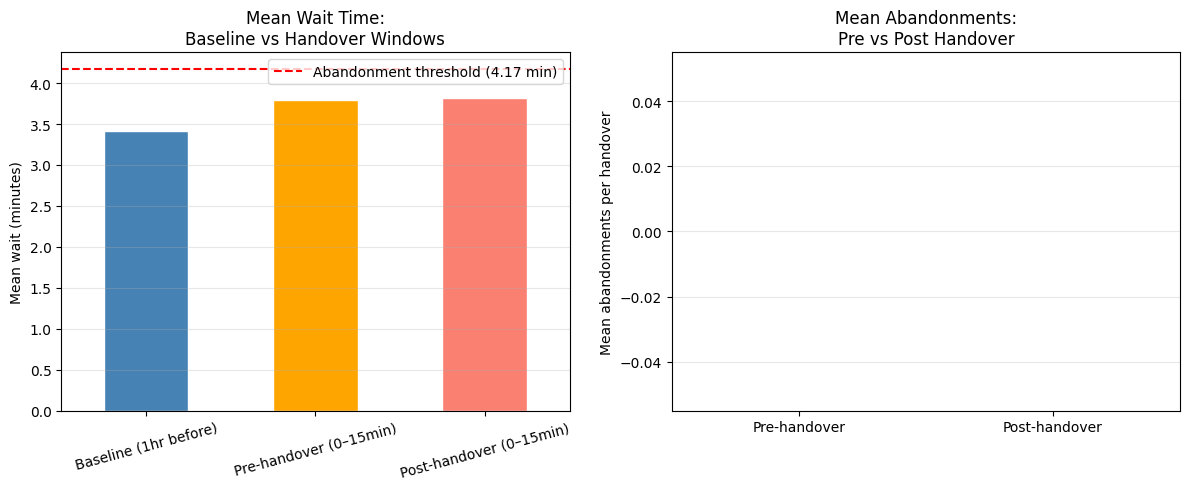

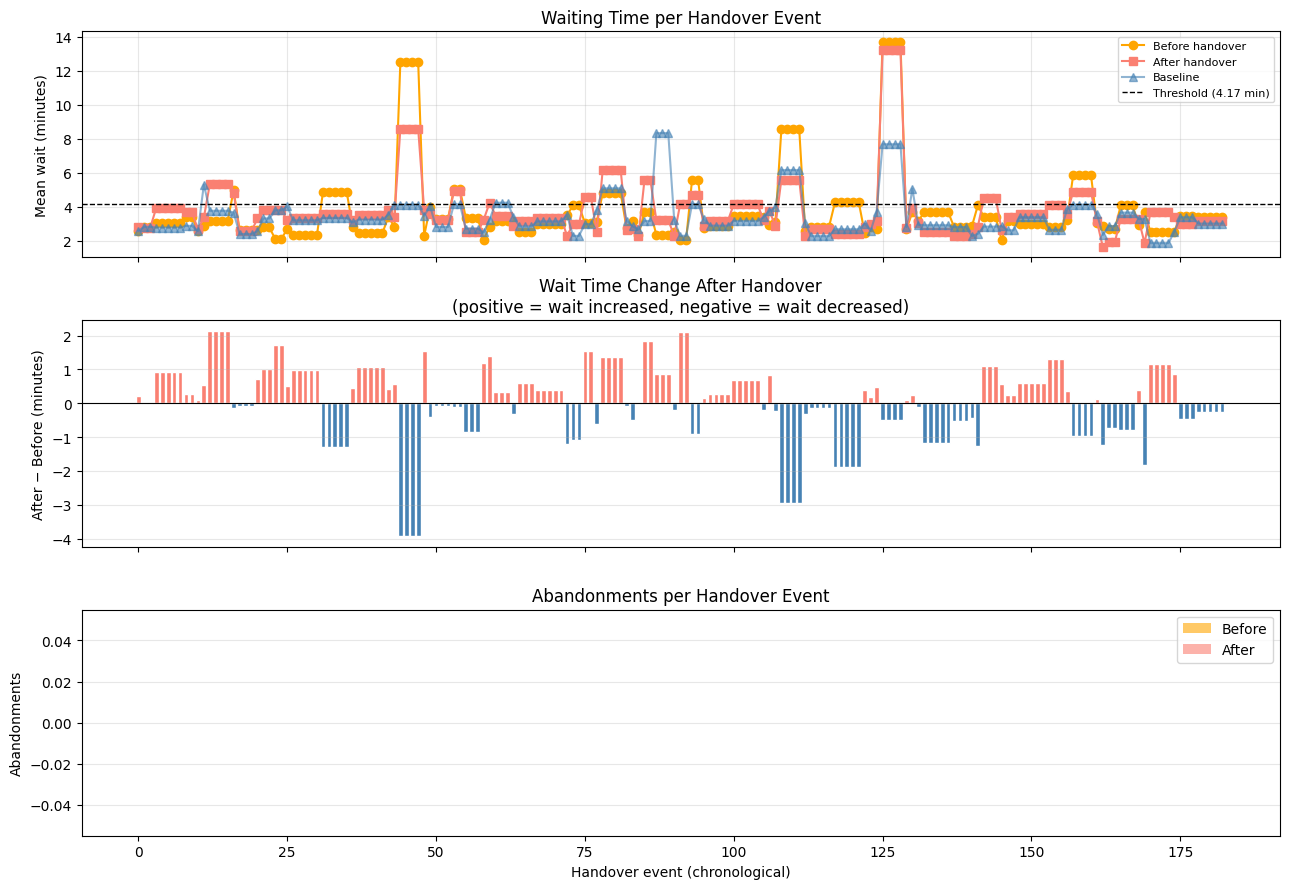


Consistency across 183 handover events:
  Wait INCREASED after handover : 54% of events
  Abandonments INCREASED after  : 0% of events
  → Wait time does NOT consistently increase → hypothesis not supported
  → Abandonment does NOT consistently increase → hypothesis not supported


In [ ]:
# Identify actual handover events

cashier_df['time:timestamp'] = pd.to_datetime(cashier_df['time:timestamp'])

end_shifts = cashier_df[
    cashier_df['concept:name'].isin(['End shift', 'End Shift'])
][['case:concept:name', 'time:timestamp']].copy()
end_shifts.columns = ['cashier_out', 'end_time']

start_shifts = cashier_df[
    cashier_df['concept:name'] == 'Start Shift'
][['case:concept:name', 'time:timestamp']].copy()
start_shifts.columns = ['cashier_in', 'start_time']

# Match each End Shift with a Start Shift within 30 minutes
HANDOVER_GAP = 30 
handover_pairs = []

for _, end_row in end_shifts.iterrows():
    window_end = end_row['end_time'] + pd.Timedelta(minutes=HANDOVER_GAP)
    matching_starts = start_shifts[
        (start_shifts['start_time'] >= end_row['end_time']) &
        (start_shifts['start_time'] <= window_end) &
        (start_shifts['cashier_in'] != end_row['cashier_out'])
    ]
    for _, start_row in matching_starts.iterrows():
        handover_pairs.append({
            'cashier_out':    end_row['cashier_out'],
            'cashier_in':     start_row['cashier_in'],
            'end_time':       end_row['end_time'],
            'start_time':     start_row['start_time'],
            'handover_time':  end_row['end_time'],  # use End Shift as anchor
            'gap_minutes':    (start_row['start_time'] - end_row['end_time']
                               ).total_seconds() / 60
        })

handover_pairs_df = pd.DataFrame(handover_pairs).drop_duplicates(
    subset=['cashier_out', 'handover_time']
)

print(f"Actual handover events identified: {len(handover_pairs_df)}")
display(handover_pairs_df.head(10))
print(f"\nGap between cashiers (minutes):")
print(handover_pairs_df['gap_minutes'].describe().round(2))

WINDOW = 15  
waiting_df['enter_queue_time'] = pd.to_datetime(waiting_df['enter_queue_time'])

handover_times_list = handover_pairs_df['handover_time'].tolist()

def nearest_handover_distance(t):
    """Return minutes to nearest handover, signed (negative = before)"""
    if not handover_times_list:
        return np.nan
    diffs = [(t - ht).total_seconds() / 60 for ht in handover_times_list]
    return min(diffs, key=abs)

# Flag each waiting customer as being near a handover or not
waiting_df['min_to_handover'] = waiting_df['enter_queue_time'].apply(
    nearest_handover_distance
)
waiting_df['handover_zone'] = pd.cut(
    waiting_df['min_to_handover'],
    bins=[-np.inf, -WINDOW, 0, WINDOW, np.inf],
    labels=['Baseline (before)', 'Pre-handover window',
            'Post-handover window', 'Baseline (after)']
)

zone_summary = (
    waiting_df
    .groupby('handover_zone', observed=True)['waiting_minutes']
    .agg(['mean', 'median', 'count', 'std'])
    .round(3)
)
print("\nWaiting time by zone relative to handover:")
display(zone_summary)

# Rebuild handover rows correctly 
WINDOW_MIN = 15

handover_rows = []
for _, row in handover_pairs_df.iterrows():
    t = row['handover_time']
    before_start = t - pd.Timedelta(minutes=WINDOW_MIN)
    after_end    = t + pd.Timedelta(minutes=WINDOW_MIN)

    before_waits = waiting_df[
        (waiting_df['enter_queue_time'] >= before_start) &
        (waiting_df['enter_queue_time'] <  t)
    ]['waiting_minutes']

    after_waits = waiting_df[
        (waiting_df['enter_queue_time'] >= t) &
        (waiting_df['enter_queue_time'] <= after_end)
    ]['waiting_minutes']

    before_abandon = customer_df[
        (customer_df['concept:name'] == 'Abandon cart and leave') &
        (customer_df['time:timestamp'] >= before_start) &
        (customer_df['time:timestamp'] <  t)
    ]['case:concept:name'].nunique()

    after_abandon = customer_df[
        (customer_df['concept:name'] == 'Abandon cart and leave') &
        (customer_df['time:timestamp'] >= t) &
        (customer_df['time:timestamp'] <= after_end)
    ]['case:concept:name'].nunique()

    baseline_start = t - pd.Timedelta(hours=1)
    baseline_end   = baseline_start + pd.Timedelta(minutes=WINDOW_MIN)
    baseline_waits = waiting_df[
        (waiting_df['enter_queue_time'] >= baseline_start) &
        (waiting_df['enter_queue_time'] <= baseline_end)
    ]['waiting_minutes']

    handover_rows.append({
        'handover_time':    t,
        'cashier_out':      row['cashier_out'],
        'cashier_in':       row['cashier_in'],
        'gap_minutes':      row['gap_minutes'],
        'avg_wait_before':  before_waits.mean(),
        'avg_wait_after':   after_waits.mean(),
        'avg_wait_baseline': baseline_waits.mean(),
        'abandon_before':   before_abandon,
        'abandon_after':    after_abandon,
        'n_before':         before_waits.count(),
        'n_after':          after_waits.count(),
        'date':             t.date(),
        'hour':             t.hour,
    })

handover_df = pd.DataFrame(handover_rows)
print(f"\nHandover analysis table: {len(handover_df)} rows")
display(handover_df.head())

# Summary comparison including baseline
summary_vals = {
    'Baseline (1hr before)': handover_df['avg_wait_baseline'].mean(),
    'Pre-handover (0–15min)': handover_df['avg_wait_before'].mean(),
    'Post-handover (0–15min)': handover_df['avg_wait_after'].mean(),
}
print("\nMean waiting time:")
for k, v in summary_vals.items():
    print(f"  {k:<30}: {v:.3f} min")

# Statistical tests
u1, p1 = stats.mannwhitneyu(
    handover_df['avg_wait_before'].dropna(),
    handover_df['avg_wait_baseline'].dropna(),
    alternative='two-sided'
)

u2, p2 = stats.mannwhitneyu(
    handover_df['avg_wait_after'].dropna(),
    handover_df['avg_wait_baseline'].dropna(),
    alternative='two-sided'
)

u3, p3 = stats.mannwhitneyu(
    handover_df['avg_wait_before'].dropna(),
    handover_df['avg_wait_after'].dropna(),
    alternative='two-sided'
)

print(f"\nMann-Whitney U tests:")
print(f"  Pre-handover vs Baseline : U={u1:.0f}, p={p1:.4f}"
      + (" *" if p1 < 0.05 else " (not significant)"))
print(f"  Post-handover vs Baseline: U={u2:.0f}, p={p2:.4f}"
      + (" *" if p2 < 0.05 else " (not significant)"))
print(f"  Pre vs Post handover     : U={u3:.0f}, p={p3:.4f}"
      + (" *" if p3 < 0.05 else " (not significant)"))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wait time
pd.Series(summary_vals).plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'orange', 'salmon'], edgecolor='white'
)
axes[0].axhline(4.17, color='red', linestyle='--',
                linewidth=1.5, label='Abandonment threshold (4.17 min)')
axes[0].set_title("Mean Wait Time:\nBaseline vs Handover Windows")
axes[0].set_ylabel("Mean wait (minutes)")
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Abandonments
abandon_vals = {
    'Pre-handover':  handover_df['abandon_before'].mean(),
    'Post-handover': handover_df['abandon_after'].mean(),
}
pd.Series(abandon_vals).plot(
    kind='bar', ax=axes[1],
    color=['orange', 'salmon'], edgecolor='white'
)
axes[1].set_title("Mean Abandonments:\nPre vs Post Handover")
axes[1].set_ylabel("Mean abandonments per handover")
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

handover_df['wait_diff'] = (
    handover_df['avg_wait_after'] - handover_df['avg_wait_before']
)
handover_df_sorted = handover_df.sort_values('handover_time')

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(range(len(handover_df_sorted)),
             handover_df_sorted['avg_wait_before'],
             marker='o', label='Before handover', color='orange')
axes[0].plot(range(len(handover_df_sorted)),
             handover_df_sorted['avg_wait_after'],
             marker='s', label='After handover', color='salmon')
axes[0].plot(range(len(handover_df_sorted)),
             handover_df_sorted['avg_wait_baseline'],
             marker='^', label='Baseline', color='steelblue', alpha=0.6)
axes[0].axhline(4.17, color='black', linestyle='--',
                linewidth=1, label='Threshold (4.17 min)')
axes[0].set_title("Waiting Time per Handover Event")
axes[0].set_ylabel("Mean wait (minutes)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(handover_df_sorted)),
            handover_df_sorted['wait_diff'],
            color=np.where(handover_df_sorted['wait_diff'] > 0, 'salmon', 'steelblue'),
            edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Wait Time Change After Handover\n(positive = wait increased, negative = wait decreased)")
axes[1].set_ylabel("After − Before (minutes)")
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(range(len(handover_df_sorted)),
            handover_df_sorted['abandon_before'],
            alpha=0.6, label='Before', color='orange', width=0.4)
axes[2].bar([x + 0.4 for x in range(len(handover_df_sorted))],
            handover_df_sorted['abandon_after'],
            alpha=0.6, label='After', color='salmon', width=0.4)
axes[2].set_title("Abandonments per Handover Event")
axes[2].set_ylabel("Abandonments")
axes[2].set_xlabel("Handover event (chronological)")
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Consistency check
pct_wait_increased = (handover_df['wait_diff'] > 0).mean() * 100
pct_abandon_increased = (
    handover_df['abandon_after'] > handover_df['abandon_before']
).mean() * 100

print(f"\nConsistency across {len(handover_df)} handover events:")
print(f"  Wait INCREASED after handover : {pct_wait_increased:.0f}% of events")
print(f"  Abandonments INCREASED after  : {pct_abandon_increased:.0f}% of events")

if pct_wait_increased >= 60:
    print("  → Wait time increase is consistent → supports hypothesis")
else:
    print("  → Wait time does NOT consistently increase → hypothesis not supported")

if pct_abandon_increased >= 60:
    print("  → Abandonment increase is consistent → supports hypothesis")
else:
    print("  → Abandonment does NOT consistently increase → hypothesis not supported")
